<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/GN_numerical_validation_report_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 수치 GN 모델 검증·비교 보고서
**G.654.E · 입력값 → NLI 적분 → SNR → 차이율 → 수렴·오차 원인**

앞서 작성한 `main_numerical_gn.py`와 원본 `main.py`의 계산 코드를 이 노트북 안에 포함했습니다.
추가 `.py` 업로드나 GitHub 접속 없이 실행할 수 있습니다. 저장된 출력은 제공 시점의 실제 실행 결과이며,
입력을 바꾸고 **런타임 → 모두 실행**하면 표·그래프·보고서 파일을 다시 생성합니다.

**사용 순서**

1. 이 `.ipynb` 파일을 Colab의 **파일 → 노트북 업로드**에서 엽니다.
2. **2. 입력 설정** 셀에서 광섬유·시스템·정밀도를 수정합니다. 기본값은 앞서 사용한 G.654.E 조건입니다.
3. 모든 셀을 실행합니다. 마지막 셀에서 HTML/CSV/JSON/PNG 묶음을 다운로드할 수 있습니다.

**이 보고서에서 구분하는 세 가지 숫자**

| 구분 | 비교 대상 | 해석 |
|---|---|---|
| 모델 간 차이율 | 원본 closed form ↔ 수치 GN | 기존 근사를 바꿨을 때의 차이; 실험 오차가 아님 |
| 수치적분 정밀도 | 샘플 수/seed 변경, 독립 적분 | 적분 계산의 안정성과 구현 확인 |
| 외부 기준 오차율 | 논문·실험·SSFM CSV ↔ 각 모델 | 같은 조건의 외부 SNR 데이터가 있을 때만 계산 |

기본 실행에는 외부 측정값이 없으므로 **논문·실험 오차율은 ‘미평가’**입니다.
Carena Fig. 5의 최대 전송거리 데이터는 SNR 데이터와 다르므로 이 CSV 입력에 직접 넣지 않습니다.

## 1. 실행 준비 및 모델 코드
필요한 패키지가 설치된 환경에서는 설치를 건너뜁니다. 아래 두 소스 셀은 접어두어도 됩니다.
원본은 지정된 git blob의 내용을 고정한 snapshot이며 fitting 함수를 호출하지 않습니다.
수치 GN은 앞서 제공한 파일의 내용을 그대로 사용합니다.

In [1]:
#@title 실행 환경 준비
import importlib.util, subprocess, sys
requirements = {"numpy": "numpy>=1.24", "scipy": "scipy>=1.10",
                "pandas": "pandas", "matplotlib": "matplotlib", "IPython": "ipython"}
missing = [requirement for module, requirement in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import os, json, math, time, warnings, types, hashlib, base64, io, html, csv
from pathlib import Path
from dataclasses import asdict, replace
from datetime import datetime, timezone
from zipfile import ZipFile, ZIP_DEFLATED
import numpy as np
import scipy
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image, FileLink
from numpy.polynomial.legendre import leggauss

REPORT_BLOCKS, TABLES, FIGURES = [], {}, {}
SOURCE_FILES = {}
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120})
pd.set_option("display.max_rows", 100)

def load_embedded_source(name, source, filename):
    module = types.ModuleType(name)
    module.__file__ = filename
    sys.modules[name] = module
    exec(compile(source, filename, "exec"), module.__dict__)
    SOURCE_FILES[filename] = source
    return module

def section(title, body=""):
    block = f"<section><h2>{html.escape(title)}</h2>{body}</section>"
    REPORT_BLOCKS.append(block)
    display(HTML(block))

def note(text, kind="note"):
    block = f'<div class="{kind}">{html.escape(text)}</div>'
    REPORT_BLOCKS.append(block)
    display(HTML(block))

def table(name, data, caption):
    frame = data.copy() if isinstance(data, pd.DataFrame) else pd.DataFrame(data)
    TABLES[name] = frame
    formatted = frame.to_html(index=False, border=0, na_rep="—", float_format=lambda x: f"{x:.6g}")
    block = f"<h3>{html.escape(caption)}</h3><div class='table-scroll'>{formatted}</div>"
    REPORT_BLOCKS.append(block)
    display(HTML(block))
    return frame

def figure(name, fig, caption):
    stream = io.BytesIO()
    fig.savefig(stream, format="png", dpi=170, bbox_inches="tight", facecolor="white")
    payload = stream.getvalue()
    FIGURES[name] = payload
    encoded = base64.b64encode(payload).decode("ascii")
    REPORT_BLOCKS.append(f'<figure><img src="data:image/png;base64,{encoded}" alt="{html.escape(caption)}">'
                         f'<figcaption>{html.escape(caption)}</figcaption></figure>')
    display(Image(data=payload))
    plt.close(fig)

print("Python", sys.version.split()[0], "| NumPy", np.__version__, "| SciPy", scipy.__version__)

Python 3.13.15 | NumPy 2.1.3 | SciPy 1.16.3


In [2]:
#@title 수치 GN 소스 — 펼치면 전체 코드 확인
NUMERICAL_SOURCE = r'''#!/usr/bin/env python3
"""수치적분 GN model: closed-form NLI 식이나 fitting 계수를 사용하지 않습니다.

Based on the input/SNR structure of kimheeseo/LSCNS/2026_KICS_Fall/main.py
Git blob SHA: 7acd0ca1379592b6ad79acbe2748da4309830083 (retrieved 2026-09-09).
Standalone: Python >= 3.10, numpy >= 1.24, scipy >= 1.10; optional matplotlib.

Reference: Poggiolini et al., 'A Detailed Analytical Derivation of the GN
Model of Non-Linear Interference in Coherent Optical Transmission Systems',
https://arxiv.org/abs/1209.0394, Eq. (96)/(G.4), with beta3 = 0.

G_NLI(f) = (16/27)*gamma**2 * double_integral[
    Gtx(f1)*Gtx(f2)*Gtx(f1+f2-f)*rho(delta_beta)*A_N(delta_beta*L)] df1 df2
rho(db) = |(1-exp(-(alpha_power-1j*db)*L))/(alpha_power-1j*db)|**2
A_N(phi) = |sum(exp(1j*n*phi), n=0..N-1)|**2  [coherent, default]
           N                                  [incoherent, explicit option]
P_NLI = integral G_NLI(f)*|H_rx(f)|**2 df = eta_link * P_channel**3.

P_channel and Gtx are TOTAL DUAL-POLARIZATION quantities. The full integral
coefficient is 16/27, not the 8/27 coefficient of the original closed form.
The paper's field attenuation alpha is alpha_power/2 in this code.

We integrate the exact finite-span kernel with randomized Sobol quadrature
and change-of-variable importance sampling. No phase averaging, center-PSD
times bandwidth approximation, asinh closed-form eta, or empirical scaling.
The analytic z integral in rho is exact for a uniform span; the GN frequency
integrals are evaluated numerically. Scramble-based uncertainty estimates
measure NUMERICAL integration uncertainty, not experimental/model error.

Scope: identical spans, ideal loss-compensating lumped EDFAs, constant alpha/
beta2/gamma, equal-power/equal-rate uniformly spaced nonoverlapping channels,
rectangular or raised-cosine PSD and matched receiver. Not EGN or SSFM.
No ISRS/Raman, beta3, PMD/PDL, ROADM filtering, or signal-ASE nonlinearity.

Examples:
  python main_numerical_gn.py --spans 30 --save-dir gn_results --plot
  python main_numerical_gn.py --spans 10 30 50 --rtol 0.001 --max-power 23
  python main_numerical_gn.py --accumulation incoherent --save-dir gn_i
"""

from __future__ import annotations

import argparse
import csv
import json
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable, Mapping, Sequence

import numpy as np
import scipy
from scipy.stats import qmc, t as student_t

C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
MANAKOV_DP = 16.0 / 27.0
SOURCE_URL = "https://github.com/kimheeseo/LSCNS/blob/main/2026_KICS_Fall/main.py"
SOURCE_SHA = "7acd0ca1379592b6ad79acbe2748da4309830083"
REFERENCE_URL = "https://arxiv.org/abs/1209.0394"


@dataclass(frozen=True)
class FiberParameters:
    name: str = "G.654.E"
    wavelength_nm: float = 1550.0
    attenuation_db_per_km: float = 0.166
    effective_area_um2: float = 125.0
    dispersion_ps_nm_km: float = 21.0
    n2_m2_w: float = 2.2e-20
    alpha_power_per_km: float | None = None
    beta2_s2_per_km: float | None = None
    gamma_per_w_km: float | None = None


@dataclass(frozen=True)
class SystemParameters:
    channels: int = 90
    symbol_rate_gbd: float = 95.0
    spacing_ghz: float = 95.0
    span_length_km: float = 80.0
    noise_figure_db: float = 5.0
    transceiver_snr_db: float = 18.0
    polarizations: int = 2
    ase_bandwidth_hz: float | None = None
    stated_gain_bandwidth_thz: float | None = 4.8
    qam_order_record_only: int = 64
    shannon_gap_db_record_only: float = 3.0


@dataclass(frozen=True)
class NumericalGNOptions:
    accumulation: str = "coherent"
    rolloff: float = 0.0
    cut_index: int | None = None  # zero-based; default channels//2 is a real channel
    min_power: int = 17          # initial points PER scramble = 2**min_power
    max_power: int = 21         # doubles until convergence or this limit
    replicates: int = 8         # independent scrambles, not repeated same points
    relative_tolerance: float = 0.005
    seed: int = 20260909
    chunk_power: int = 15       # limits temporary array memory, not precision


def _positive(name: str, value: float, allow_zero: bool = False) -> None:
    if not np.isfinite(value) or (value < 0 if allow_zero else value <= 0):
        raise ValueError(f"{name}: finite {'nonnegative' if allow_zero else 'positive'} value required")


def _integer(name: str, value: int, minimum: int = 1) -> int:
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, (int, np.integer)) or value < minimum:
        raise ValueError(f"{name}: integer >= {minimum} required")
    return int(value)


def derive_parameters(fiber: FiberParameters = FiberParameters(),
                      system: SystemParameters = SystemParameters()) -> dict:
    """원본과 같은 단위 변환, loss compensation, ASE convention."""
    _integer("channels", system.channels)
    if system.polarizations != 2:
        raise ValueError("This implementation requires total dual-polarization channel power.")
    for key in ("wavelength_nm", "effective_area_um2", "n2_m2_w"):
        _positive(key, getattr(fiber, key))
    for key in ("symbol_rate_gbd", "spacing_ghz", "span_length_km"):
        _positive(key, getattr(system, key))
    _positive("noise_figure_db", system.noise_figure_db, allow_zero=True)
    if not np.isfinite(system.transceiver_snr_db):
        raise ValueError("transceiver_snr_db must be finite; disable TRX explicitly instead.")
    if system.ase_bandwidth_hz is not None:
        _positive("ase_bandwidth_hz", system.ase_bandwidth_hz)
    if system.stated_gain_bandwidth_thz is not None:
        _positive("stated_gain_bandwidth_thz", system.stated_gain_bandwidth_thz)
    wavelength = fiber.wavelength_nm * 1e-9
    rs = system.symbol_rate_gbd * 1e9
    alpha = (fiber.attenuation_db_per_km * np.log(10) / 10
             if fiber.alpha_power_per_km is None else fiber.alpha_power_per_km)
    beta2 = (-wavelength**2 / (2 * np.pi * C0) * fiber.dispersion_ps_nm_km * 1e-3
             if fiber.beta2_s2_per_km is None else fiber.beta2_s2_per_km)
    gamma = (2 * np.pi * fiber.n2_m2_w / (wavelength * fiber.effective_area_um2 * 1e-12) * 1e3
             if fiber.gamma_per_w_km is None else fiber.gamma_per_w_km)
    _positive("alpha_power_per_km", alpha)
    _positive("gamma_per_w_km", gamma, allow_zero=True)
    if not np.isfinite(beta2):
        raise ValueError("beta2 must be finite")
    optical_depth = alpha * system.span_length_km
    if optical_depth > 100 or abs(system.transceiver_snr_db) > 300 or system.noise_figure_db > 100:
        raise ValueError("Gain/noise inputs outside supported numerical range")
    gain = np.exp(optical_depth)
    ase_bw = rs if system.ase_bandwidth_hz is None else system.ase_bandwidth_hz
    return {
        "wavelength_m": wavelength, "frequency_hz": C0 / wavelength,
        "rate_hz": rs, "spacing_hz": system.spacing_ghz * 1e9,
        "alpha_power_per_km": float(alpha), "alpha_field_per_km": float(alpha / 2),
        "beta2_s2_per_km": float(beta2), "beta2_ps2_per_km": float(beta2 * 1e24),
        "gamma_per_w_km": float(gamma),
        "effective_length_km": float(-np.expm1(-optical_depth) / alpha),
        "asymptotic_length_km": float(1 / alpha),
        "attenuation_db_per_km_used": float(alpha * 10 / np.log(10)),
        "span_gain_db": float(optical_depth * 10 / np.log(10)),
        "span_gain_linear": float(gain), "ase_bandwidth_hz": float(ase_bw),
        "ase_per_span_w": float(H_PLANCK * C0 / wavelength * 10**(system.noise_figure_db / 10)
                                * ase_bw * np.expm1(optical_depth)),
        "wdm_occupied_bandwidth_thz": system.channels * system.spacing_ghz / 1000,
    }


def _validate_options(options: NumericalGNOptions, system: SystemParameters) -> int:
    if options.accumulation not in ("coherent", "incoherent"):
        raise ValueError("accumulation must be coherent or incoherent")
    if not np.isfinite(options.rolloff) or not 0 <= options.rolloff <= 1:
        raise ValueError("rolloff must lie in [0, 1]")
    if system.channels > 1 and system.spacing_ghz < system.symbol_rate_gbd * (1 + options.rolloff) * (1 - 1e-12):
        raise ValueError("Overlapping WDM channels are not supported: spacing >= Rs*(1+rolloff) required.")
    cut = system.channels // 2 if options.cut_index is None else _integer("cut_index", options.cut_index, 0)
    if cut >= system.channels:
        raise ValueError("cut_index must be less than channels")
    for key in ("min_power", "max_power", "chunk_power"):
        _integer(key, getattr(options, key))
    if not 4 <= options.min_power < options.max_power <= 28:
        raise ValueError("Require 4 <= min_power < max_power <= 28 (at least two refinement levels).")
    _integer("replicates", options.replicates, 4)
    _integer("seed", options.seed, 0)
    if not 0 < options.relative_tolerance < 1:
        raise ValueError("relative_tolerance must lie strictly between 0 and 1")
    return cut


def raised_cosine_psd(x: np.ndarray, rolloff: float = 0.0) -> np.ndarray:
    """Dimensionless RC power spectrum; integral over x=f/Rs is one."""
    ax = np.abs(np.asarray(x, dtype=float))
    if rolloff == 0:
        return (ax <= 0.5).astype(float)
    transition = np.clip((ax - (1 - rolloff) / 2) / rolloff, 0, 1)
    return 0.5 * (1 + np.cos(np.pi * transition))


def wdm_psd_shape(x: np.ndarray, system: SystemParameters,
                  options: NumericalGNOptions) -> np.ndarray:
    """S(x), such that Gtx(f)=P_channel/Rs*S(f/Rs). Gaps remain zero."""
    x = np.asarray(x, dtype=float)
    if system.channels == 1:
        return raised_cosine_psd(x, options.rolloff)
    cut = system.channels // 2 if options.cut_index is None else options.cut_index
    spacing = system.spacing_ghz / system.symbol_rate_gbd
    first = -cut * spacing
    nearest = np.rint((x - first) / spacing).astype(np.int64)
    valid = (nearest >= 0) & (nearest < system.channels)
    offset = x - (first + nearest * spacing)
    return np.where(valid, raised_cosine_psd(offset, options.rolloff), 0.0)


def coherent_accumulation(phase: np.ndarray, spans: int) -> np.ndarray:
    """Exact finite geometric sum squared, stable at phase = 2*pi*k."""
    spans = _integer("spans", spans)
    phase = np.asarray(phase, dtype=float)
    if spans == 1:
        return np.ones_like(phase)
    wrapped = np.remainder(phase + np.pi, 2 * np.pi) / (2 * np.pi) - 0.5
    return (spans * np.sinc(spans * wrapped) / np.sinc(wrapped))**2


def single_span_kernel(delta_beta: np.ndarray, alpha_power: float, length: float) -> np.ndarray:
    """rho in km^2. Finite-length numerator retained even at high loss."""
    db = np.asarray(delta_beta, dtype=float)
    loss = np.exp(-alpha_power * length)
    numerator = np.expm1(-alpha_power * length)**2 + 4 * loss * np.sin(db * length / 2)**2
    return numerator / (alpha_power**2 + db**2)


def _sample_integrand(points: np.ndarray, parameters: Mapping, system: SystemParameters,
                      options: NumericalGNOptions) -> tuple[np.ndarray, np.ndarray]:
    """Return importance-weighted single-span eta samples and EXACT phases.

    x = f/Rs; u = (f1-f)/Rs; v = (f2-f)/Rs. All powers of Rs cancel
    between the three PSD factors and df1*df2*df. Sinh in u resolves the
    narrow phase-matching ridges; arctan in v cancels the Lorentz denominator.
    These are changes of variables with their Jacobians, not fitted models.
    """
    alpha = parameters["alpha_power_per_km"]
    kappa = 4 * np.pi**2 * parameters["beta2_s2_per_km"] * parameters["rate_hz"]**2
    gamma = parameters["gamma_per_w_km"]
    length = system.span_length_km
    cut = system.channels // 2 if options.cut_index is None else options.cut_index
    spacing = system.spacing_ghz / system.symbol_rate_gbd
    half = (1 + options.rolloff) / 2
    band_lo, band_hi = -cut * spacing - half, (system.channels - 1 - cut) * spacing + half
    x = (2 * points[:, 0] - 1) * half
    u_lo, u_hi = band_lo - x, band_hi - x
    # For very weak dispersion use uniform variables to avoid small-number loss.
    weak = abs(kappa) * (band_hi - band_lo + 2 * half)**2 / alpha < 1e-4
    if weak:
        u_jac = u_hi - u_lo
        u = u_lo + points[:, 1] * u_jac
    else:
        scale = alpha / (abs(kappa) * (band_hi - band_lo + 2 * half))
        t_lo, t_hi = np.arcsinh(u_lo / scale), np.arcsinh(u_hi / scale)
        t = t_lo + points[:, 1] * (t_hi - t_lo)
        u = scale * np.sinh(t)
        u_jac = scale * np.cosh(t) * (t_hi - t_lo)
    v_lo = np.maximum(band_lo - x, band_lo - x - u)
    v_hi = np.minimum(band_hi - x, band_hi - x - u)
    b = np.abs(kappa * u)
    ratio = b / alpha
    near_zero = ratio * np.maximum(np.abs(v_lo), np.abs(v_hi)) < 1e-5
    v = np.empty_like(u)
    kernel_jac = np.empty_like(u)
    # Exact uniform transform where the arctan transform would be ill-conditioned.
    v[near_zero] = v_lo[near_zero] + points[near_zero, 2] * (v_hi - v_lo)[near_zero]
    kernel_jac[near_zero] = (v_hi - v_lo)[near_zero] / (
        alpha**2 + (kappa * u[near_zero] * v[near_zero])**2)
    far = ~near_zero
    q = ratio[far]
    theta_lo = np.arctan(q * v_lo[far])
    # atan2 avoids cancellation when both atan endpoints approach +/-pi/2.
    theta_width = np.arctan2(q * (v_hi - v_lo)[far], 1 + (q * v_lo[far]) * (q * v_hi[far]))
    theta = theta_lo + points[far, 2] * theta_width
    v[far] = np.tan(theta) / q
    kernel_jac[far] = theta_width / (alpha * b[far])
    phase = kappa * u * v * length
    numerator = np.expm1(-alpha * length)**2 + 4 * np.exp(-alpha * length) * np.sin(phase / 2)**2
    spectra = (wdm_psd_shape(x + u, system, options) * wdm_psd_shape(x + v, system, options)
               * wdm_psd_shape(x + u + v, system, options))
    weight = (MANAKOV_DP * gamma**2 * (2 * half) * raised_cosine_psd(x, options.rolloff)
              * spectra * u_jac * numerator * kernel_jac)
    if not np.all(np.isfinite(weight)) or not np.all(np.isfinite(phase)):
        raise FloatingPointError("Non-finite integrand. Check physical inputs/range.")
    return weight, phase


def _relative(numerator: np.ndarray, denominator: np.ndarray) -> np.ndarray:
    return np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator != 0)


def numerical_gn_eta(spans: int | Sequence[int] = 30, *,
                     fiber: FiberParameters = FiberParameters(),
                     system: SystemParameters = SystemParameters(),
                     options: NumericalGNOptions = NumericalGNOptions(),
                     progress: Callable[[dict], None] | None = None) -> dict:
    """Compute eta_link [W^-2] for one/multiple span counts, with convergence.

    Refines nested 2**m Sobol point sets. Independent scrambles estimate
    standard error; Student-t produces an estimated 95% half-width.
    Stop only when BOTH relative half-width and change from the preceding
    level meet the tolerance for ALL requested span counts. This is a
    diagnostic, not a rigorous error bound; check another seed for new cases.
    Unconverged estimates are returned with converged=False and a warning.
    """
    parameters = derive_parameters(fiber, system)
    cut = _validate_options(options, system)
    raw_spans = [spans] if np.isscalar(spans) else list(spans)
    counts = sorted(set(_integer("spans", n) for n in raw_spans))
    if not counts:
        raise ValueError("spans cannot be empty")
    messages = []
    support_thz = ((system.channels - 1) * system.spacing_ghz
                   + system.symbol_rate_gbd * (1 + options.rolloff)) / 1000
    if system.stated_gain_bandwidth_thz is not None and support_thz > system.stated_gain_bandwidth_thz:
        messages.append(f"WDM support {support_thz:g} THz exceeds stated amplifier bandwidth "
                        f"{system.stated_gain_bandwidth_thz:g} THz. Inputs retained; ideal flat gain assumed.")
    if support_thz > 5:
        messages.append("Wideband case: ISRS and frequency-dependent fiber/amplifier parameters are omitted.")
    if system.ase_bandwidth_hz is not None and not np.isclose(system.ase_bandwidth_hz, parameters["rate_hz"]):
        messages.append("ASE bandwidth override differs from matched-filter noise bandwidth Rs; legacy ASE convention retained.")
    if parameters["beta2_s2_per_km"] == 0:
        messages.append("Zero dispersion is allowed for mathematical tests; GN Gaussianity is not physically validated here.")
    for message in messages:
        warnings.warn(message, RuntimeWarning, stacklevel=2)
    engines = [qmc.Sobol(d=3, scramble=True, seed=int(s.generate_state(1)[0]))
               for s in np.random.SeedSequence(options.seed).spawn(options.replicates)]
    sums = np.zeros((options.replicates, len(counts)))
    history, previous, total = [], None, 0
    critical = float(student_t.ppf(0.975, options.replicates - 1))
    started = time.perf_counter()
    converged = False
    for power in range(options.min_power, options.max_power + 1):
        additional = 2**power - total
        for rep, engine in enumerate(engines):
            remaining = additional
            while remaining:
                size = min(remaining, 2**options.chunk_power)
                # Successive contiguous dyadic blocks; each tested total is 2**power.
                points = engine.random(size)
                base, phase = _sample_integrand(points, parameters, system, options)
                for j, n in enumerate(counts):
                    if options.accumulation == "incoherent":
                        sums[rep, j] += n * np.sum(base, dtype=np.float64)
                    else:
                        sums[rep, j] += np.sum(base * coherent_accumulation(phase, n), dtype=np.float64)
                remaining -= size
        total = 2**power
        estimates = sums / total
        mean = np.mean(estimates, axis=0)
        half95 = critical * np.std(estimates, axis=0, ddof=1) / np.sqrt(options.replicates)
        rel95 = _relative(half95, mean)
        change = None if previous is None else _relative(np.abs(mean - previous), mean)
        converged = bool(change is not None and np.all(rel95 <= options.relative_tolerance)
                         and np.all(change <= options.relative_tolerance))
        state = {"power": power, "samples_per_replicate": total,
                 "eta_link_w_inv2": mean.tolist(), "relative_ci95_halfwidth": rel95.tolist(),
                 "relative_change": None if change is None else change.tolist(),
                 "elapsed_seconds": time.perf_counter() - started, "converged": converged}
        history.append(state)
        if progress:
            progress(state)
        if converged:
            break
        previous = mean.copy()
    if not converged:
        message = "Integration did NOT meet the requested tolerance; increase max_power/replicates and verify with another seed."
        messages.append(message)
        warnings.warn(message, RuntimeWarning, stacklevel=2)
    return {
        "spans": counts, "eta_link_w_inv2": mean.tolist(),
        "ci95_halfwidth_w_inv2": half95.tolist(), "relative_ci95_halfwidth": rel95.tolist(),
        "replicate_eta_link_w_inv2": estimates.tolist(), "converged": converged,
        "history": history, "samples_per_replicate": total,
        "total_integrand_evaluations": total * options.replicates,
        "elapsed_seconds": time.perf_counter() - started,
        "fiber": asdict(fiber), "system": asdict(system), "options": asdict(options),
        "parameters": parameters, "cut_index_used": cut, "wdm_support_thz": support_thz,
        "power_definition": "total_dp_per_channel", "integral_coefficient": MANAKOV_DP,
        "uncertainty_kind": "estimated numerical integration uncertainty; NOT physical/model validation error",
        "warnings": messages, "source_url": SOURCE_URL, "source_git_blob_sha": SOURCE_SHA,
        "reference_url": REFERENCE_URL,
        "versions": {"python": sys.version.split()[0], "numpy": np.__version__, "scipy": scipy.__version__},
    }


def calculate_snr(launch_dbm: Sequence[float] | float, spans: int, eta_link: float,
                  parameters: Mapping, system: SystemParameters, *,
                  include_transceiver_noise: bool = True) -> dict[str, np.ndarray]:
    """Same SNR budget as main.py; eta_link ALREADY includes all spans.

    IMPORTANT migration difference: third argument is eta_link, NOT eta_per_span.
    Do not multiply NLI by spans again. P is total DP power PER CHANNEL.
    """
    spans = _integer("spans", spans)
    _positive("eta_link", eta_link, allow_zero=True)
    launch = np.atleast_1d(np.asarray(launch_dbm, dtype=float))
    if launch.ndim != 1 or launch.size == 0 or not np.all(np.isfinite(launch)) or np.any(np.abs(launch) > 100):
        raise ValueError("launch_dbm must be a nonempty finite 1-D array within [-100, 100]")
    signal = 1e-3 * 10**(launch / 10)
    ase = np.full_like(signal, spans * parameters["ase_per_span_w"])
    nli = eta_link * signal**3
    trx = signal / 10**(system.transceiver_snr_db / 10) if include_transceiver_noise else np.zeros_like(signal)
    noise = ase + nli + trx
    snr = signal / noise
    return {"launch_dbm": launch, "spans": np.full(launch.shape, spans, dtype=int),
            "distance_km": np.full(launch.shape, spans * system.span_length_km),
            "signal_w": signal, "ase_w": ase, "nli_w": nli,
            "trx_equivalent_noise_w": trx, "total_noise_w": noise,
            "snr_linear": snr, "snr_db": 10 * np.log10(snr),
            "eta_link_w_inv2": np.full(launch.shape, eta_link)}


def simulate_snr_curve(launch_dbm: Sequence[float] | float, spans: int,
                       fiber: FiberParameters = FiberParameters(),
                       system: SystemParameters = SystemParameters(),
                       options: NumericalGNOptions = NumericalGNOptions(), *,
                       include_transceiver_noise: bool = True) -> dict:
    """Single-span-count convenience API. Returns columns, like main.py without pandas.

    For sweeps over span counts, use numerical_gn_eta once, then calculate_snr
    for each eta_link. Do not redo the integral for every launch power.
    """
    result = numerical_gn_eta(spans, fiber=fiber, system=system, options=options)
    if not result["converged"]:
        raise RuntimeError("Unconverged integral. Inspect numerical_gn_eta diagnostics or raise max_power.")
    return calculate_snr(launch_dbm, spans, result["eta_link_w_inv2"][0], result["parameters"], system,
                         include_transceiver_noise=include_transceiver_noise)


def analytical_optimum_launch_dbm(eta_link: float, spans: int, parameters: Mapping) -> float:
    """Exact optimum of this scalar noise budget, NOT a closed-form GN eta.

    Popt=(N*ASE_per_span/(2*eta_link))**(1/3). Constant TRX SNR does not
    shift this optimum. This does not impose a reach/BER or FEC threshold.
    """
    _positive("eta_link", eta_link)
    _integer("spans", spans)
    power = (spans * parameters["ase_per_span_w"] / (2 * eta_link))**(1 / 3)
    return float(10 * np.log10(power / 1e-3))


def error_metrics(reference_snr_db: Sequence[float], predicted_snr_db: Sequence[float]) -> dict:
    """External-reference metrics on the SAME points; never used to fit eta."""
    ref, pred = np.asarray(reference_snr_db, float), np.asarray(predicted_snr_db, float)
    if ref.shape != pred.shape or ref.ndim != 1 or ref.size == 0 or not np.all(np.isfinite([ref, pred])):
        raise ValueError("reference and prediction must be finite equal-length 1-D arrays")
    residual = pred - ref
    return {"samples": int(ref.size), "bias_db": float(np.mean(residual)),
            "mae_db": float(np.mean(np.abs(residual))),
            "rmse_db": float(np.sqrt(np.mean(residual**2))),
            "max_abs_db": float(np.max(np.abs(residual))),
            "mape_linear_snr_percent": float(np.mean(np.abs(10**(residual / 10) - 1)) * 100)}


def _progress(state: dict) -> None:
    rel = max(state["relative_ci95_halfwidth"]) * 100
    change = state["relative_change"]
    change_text = "n/a" if change is None else f"{max(change)*100:.4f}%"
    print(f"2^{state['power']}/scramble: estimated 95% half-width <= {rel:.4f}%, "
          f"level change <= {change_text}, {state['elapsed_seconds']:.1f}s", flush=True)


def run_cli(argv: Sequence[str] | None = None) -> int:
    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    parser.add_argument("--spans", type=int, nargs="+", default=[30])
    parser.add_argument("--channels", type=int, default=90)
    parser.add_argument("--symbol-rate-gbd", type=float, default=95)
    parser.add_argument("--spacing-ghz", type=float, default=95)
    parser.add_argument("--span-length-km", type=float, default=80)
    parser.add_argument("--attenuation-db-per-km", type=float, default=0.166)
    parser.add_argument("--dispersion-ps-nm-km", type=float, default=21)
    parser.add_argument("--effective-area-um2", type=float, default=125)
    parser.add_argument("--n2-m2-w", type=float, default=2.2e-20)
    parser.add_argument("--wavelength-nm", type=float, default=1550)
    parser.add_argument("--noise-figure-db", type=float, default=5)
    parser.add_argument("--transceiver-snr-db", type=float, default=18)
    parser.add_argument("--stated-gain-bandwidth-thz", type=float, default=4.8,
                        help="Informational only; never used to truncate channels")
    parser.add_argument("--no-trx", action="store_true")
    parser.add_argument("--accumulation", choices=["coherent", "incoherent"], default="coherent")
    parser.add_argument("--rolloff", type=float, default=0)
    parser.add_argument("--cut-index", type=int)
    parser.add_argument("--min-power", type=int, default=17)
    parser.add_argument("--max-power", type=int, default=21)
    parser.add_argument("--replicates", type=int, default=8)
    parser.add_argument("--rtol", type=float, default=0.005)
    parser.add_argument("--seed", type=int, default=20260909)
    parser.add_argument("--launch-min-dbm", type=float, default=-10)
    parser.add_argument("--launch-max-dbm", type=float, default=10)
    parser.add_argument("--launch-step-dbm", type=float, default=0.25)
    parser.add_argument("--save-dir", type=Path)
    parser.add_argument("--overwrite", action="store_true", help="Allow replacing this program's named output files")
    parser.add_argument("--allow-unconverged", action="store_true", help="Keep warning/flag but exit 0 instead of 2")
    parser.add_argument("--plot", action="store_true")
    parser.add_argument("--reference-csv", type=Path,
                        help="CSV columns: spans, launch_dbm, snr_db; same conditions required, no fitting")
    args = parser.parse_args(argv)
    if not np.all(np.isfinite([args.launch_min_dbm, args.launch_max_dbm, args.launch_step_dbm])):
        parser.error("Launch grid must be finite")
    if args.launch_step_dbm <= 0 or not -100 <= args.launch_min_dbm <= args.launch_max_dbm <= 100:
        parser.error("Invalid launch range or step")
    intervals = int(np.floor((args.launch_max_dbm - args.launch_min_dbm) / args.launch_step_dbm + 1e-10))
    if intervals > 1_000_000:
        parser.error("Launch grid too large")
    launch = args.launch_min_dbm + np.arange(intervals + 1) * args.launch_step_dbm
    if args.plot and args.save_dir is None:
        parser.error("--plot requires --save-dir")
    if args.save_dir:
        targets = ["gn_report.json", "snr_curves.csv"] + (["snr_curves.png"] if args.plot else [])
        existing = [str(args.save_dir / name) for name in targets if (args.save_dir / name).exists()]
        if existing and not args.overwrite:
            parser.error("Output exists; select a new --save-dir or explicitly --overwrite: " + ", ".join(existing))
    fiber = FiberParameters(wavelength_nm=args.wavelength_nm, attenuation_db_per_km=args.attenuation_db_per_km,
                            dispersion_ps_nm_km=args.dispersion_ps_nm_km, effective_area_um2=args.effective_area_um2,
                            n2_m2_w=args.n2_m2_w)
    system = SystemParameters(channels=args.channels, symbol_rate_gbd=args.symbol_rate_gbd,
                              spacing_ghz=args.spacing_ghz, span_length_km=args.span_length_km,
                              noise_figure_db=args.noise_figure_db, transceiver_snr_db=args.transceiver_snr_db,
                              stated_gain_bandwidth_thz=args.stated_gain_bandwidth_thz)
    options = NumericalGNOptions(accumulation=args.accumulation, rolloff=args.rolloff, cut_index=args.cut_index,
                                 min_power=args.min_power, max_power=args.max_power, replicates=args.replicates,
                                 relative_tolerance=args.rtol, seed=args.seed)
    result = numerical_gn_eta(args.spans, fiber=fiber, system=system, options=options, progress=_progress)
    result["include_transceiver_noise"] = not args.no_trx
    curves, optima = [], []
    for n, eta in zip(result["spans"], result["eta_link_w_inv2"]):
        curve = calculate_snr(launch, n, eta, result["parameters"], system, include_transceiver_noise=not args.no_trx)
        curves.append(curve)
        if eta > 0:
            optimum = analytical_optimum_launch_dbm(eta, n, result["parameters"])
            snr_opt = calculate_snr(optimum, n, eta, result["parameters"], system,
                                    include_transceiver_noise=not args.no_trx)["snr_db"][0]
            optima.append({"spans": n, "optimum_launch_dbm": optimum, "optimum_snr_db": float(snr_opt)})
            print(f"N={n}: eta_link={eta:.8g} W^-2, Popt={optimum:.4f} dBm/channel (total DP), GSNR={snr_opt:.4f} dB")
    result["optima"] = optima
    if args.reference_csv:
        with args.reference_csv.open(newline="", encoding="utf-8-sig") as stream:
            rows = list(csv.DictReader(stream))
        if not rows or not {"spans", "launch_dbm", "snr_db"}.issubset(rows[0]):
            parser.error("Reference CSV requires nonempty spans,launch_dbm,snr_db columns")
        lookup = dict(zip(result["spans"], result["eta_link_w_inv2"]))
        references, predictions = [], []
        for row in rows:
            n = int(row["spans"])
            if n not in lookup:
                parser.error(f"Reference span {n} was not requested in --spans")
            pred = calculate_snr(float(row["launch_dbm"]), n, lookup[n], result["parameters"], system,
                                 include_transceiver_noise=not args.no_trx)["snr_db"][0]
            references.append(float(row["snr_db"]))
            predictions.append(float(pred))
        result["reference_metrics"] = error_metrics(references, predictions)
        result["reference_csv"] = str(args.reference_csv)
        print("External-reference comparison (conditions must match):", result["reference_metrics"])
    if args.save_dir:
        args.save_dir.mkdir(parents=True, exist_ok=True)
        with (args.save_dir / "gn_report.json").open("w", encoding="utf-8") as stream:
            json.dump(result, stream, ensure_ascii=False, indent=2, allow_nan=False)
        with (args.save_dir / "snr_curves.csv").open("w", newline="", encoding="utf-8") as stream:
            writer = csv.writer(stream)
            writer.writerow([*curves[0], "integration_converged"])
            for curve in curves:
                writer.writerows([*row, result["converged"]] for row in zip(*curve.values()))
        if args.plot:
            import matplotlib
            matplotlib.use("Agg")
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(figsize=(8, 5))
            for curve in curves:
                ax.plot(curve["launch_dbm"], curve["snr_db"], label=f"{curve['spans'][0]} spans")
            ax.set(xlabel="Launch power per channel, total DP (dBm)", ylabel="GSNR (dB)",
                   title="Numerical GN: " + options.accumulation + ("" if result["converged"] else " [UNCONVERGED]"))
            ax.grid(alpha=0.3)
            ax.legend()
            fig.tight_layout()
            fig.savefig(args.save_dir / "snr_curves.png", dpi=180)
            plt.close(fig)
    print("Convergence:", result["converged"], "(numerical criterion only; no paper/experiment accuracy claim)")
    return 0 if result["converged"] or args.allow_unconverged else 2


if __name__ == "__main__":
    raise SystemExit(run_cli())
'''
gn = load_embedded_source('gn_numerical_report', NUMERICAL_SOURCE, 'main_numerical_gn.py')
NUMERICAL_SHA256 = hashlib.sha256(NUMERICAL_SOURCE.encode()).hexdigest()
print('수치 GN 로드 완료 | SHA-256:', NUMERICAL_SHA256)

수치 GN 로드 완료 | SHA-256: 237bde9d149409ea4c17dea4d76e5747dd47e89ba7e92cab51e97350c7a7d838


In [3]:
#@title 원본 main.py snapshot — 비교 시 fitting 함수는 호출하지 않음
ORIGINAL_SOURCE = r'''"""Reusable GN-model engine and validation CLI.

This file is a reusable version of the attached G.654.E notebook/report code.
It keeps the same closed-form GN approximation and the same default conditions,
but removes the notebook-only fixed input block and the image-specific fitting.

Default conventions:
  - launch power is total dual-polarization channel power
  - GN coefficient is 8/27
  - NLI accumulation is incoherent and proportional to span count
  - ASE bandwidth is the symbol rate, matching the attached code
  - one loss-compensating EDFA is used per span

The 8/27 coefficient is not silently changed. If another implementation uses
4/27, 16/27, per-polarization power, or a different ASE bandwidth, pass those
choices explicitly and record them in the returned metadata.

Typical import:

    from main import (
        FiberParameters, SystemParameters, GNOptions,
        simulate_snr_curve, validate_gn_model,
    )

    fiber = FiberParameters(
        name="G.654.E",
        attenuation_db_per_km=0.166,
        effective_area_um2=125.0,
        dispersion_ps_nm_km=21.0,
        n2_m2_w=2.2e-20,
    )
    system = SystemParameters(
        channels=90,
        symbol_rate_gbd=95.0,
        spacing_ghz=95.0,
        span_length_km=80.0,
        noise_figure_db=5.0,
        transceiver_snr_db=18.0,
    )
    options = GNOptions(nli_coefficient=8/27, finite_effective_length=True)

    result = validate_gn_model(
        launch_dbm=[-10, -5, 0, 4, 8, 10],
        spans=30,
        fiber=fiber,
        system=system,
        options=options,
        reference_snr_db=external_snr_db,
    )
    print(result["validation"]["metrics"])

CLI:
    python main.py --model finite --spans 1,10,30,50 --save-dir gn_results
    python main.py --reference-csv other_model.csv --spans 30
    python main.py --figure5 --save-dir carena_fig5_results

The reference CSV must contain launch_dbm and snr_db columns. If it contains
spans, the selected span is used.
"""

from __future__ import annotations

import argparse
import csv
import json
import platform
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, Mapping, Optional, Sequence, Tuple

import numpy as np

try:
    import pandas as pd
except ImportError:  # pandas is optional for library use
    pd = None


# ---------------------------------------------------------------------------
# Input models
# ---------------------------------------------------------------------------


@dataclass(frozen=True)
class FiberParameters:
    """Fiber parameters.

    alpha_power_per_km, beta2_s2_per_km, and gamma_per_w_km are optional direct
    overrides. When omitted, they are derived from the usual fiber inputs.
    """

    name: str = "G.654.E"
    wavelength_nm: float = 1550.0
    attenuation_db_per_km: float = 0.166
    effective_area_um2: float = 125.0
    dispersion_ps_nm_km: float = 21.0
    n2_m2_w: float = 2.2e-20
    alpha_power_per_km: Optional[float] = None
    beta2_s2_per_km: Optional[float] = None
    gamma_per_w_km: Optional[float] = None


@dataclass(frozen=True)
class SystemParameters:
    """System and transceiver parameters.

    The attached code uses symbol rate as the ASE noise bandwidth. That
    behavior is retained by leaving ase_bandwidth_hz as None.
    """

    channels: int = 90
    symbol_rate_gbd: float = 95.0
    spacing_ghz: float = 95.0
    span_length_km: float = 80.0
    noise_figure_db: float = 5.0
    transceiver_snr_db: float = 18.0
    polarizations: int = 2
    ase_bandwidth_hz: Optional[float] = None
    stated_gain_bandwidth_thz: Optional[float] = 4.8
    qam_order_record_only: int = 64
    shannon_gap_db_record_only: float = 3.0


@dataclass(frozen=True)
class GNOptions:
    """GN-model conventions.

    nli_coefficient=8/27 is the default used in the attached code for total
    dual-polarization channel power. The code does not infer a different
    coefficient from polarizations, because that would hide a convention
    mismatch during validation.
    """

    nli_coefficient: float = 8.0 / 27.0
    finite_effective_length: bool = True
    power_definition: str = "total_dp"
    nli_channel_count: Optional[float] = None
    model_name: str = "gn_finite"


C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
DB_PER_NEPER_POWER = 10.0 / np.log(10.0)


# ---------------------------------------------------------------------------
# Carena et al. (JLT 2012) Figure 5 validation data
# ---------------------------------------------------------------------------


# These are digitized/rounded Figure 5 markers, kept here so the validation
# can be run with main.py alone. They are not a replacement for the paper's
# raw simulation data. The source conditions are the 32-GBaud, 100-km-span,
# 9-channel cases documented in the repository's validation notebook.
FIG5_REQUIRED_OSNR_DB_PER_0P1NM: Dict[str, Dict[float, float]] = {
    "PM-BPSK": {
        50.0: 10.95,
        38.4: 11.12,
        35.2: 11.38,
        33.6: 11.77,
        32.8: 12.05,
        32.0: 12.40,
    },
    "PM-QPSK": {
        50.0: 13.95,
        38.4: 14.15,
        35.2: 14.65,
        33.6: 15.20,
        32.8: 15.65,
        32.0: 16.25,
    },
    "PM-8QAM": {
        50.0: 18.10,
        38.4: 18.52,
        35.2: 19.69,
        33.6: 21.62,
        32.8: 24.40,
    },
    "PM-16QAM": {
        50.0: 20.65,
        38.4: 21.85,
        36.8: 22.35,
        35.2: 24.54,
    },
}

FIG5_REFERENCE_REACH_KM: Dict[
    str, Dict[str, Dict[float, float]]
] = {
    "PSCF": {
        "PM-BPSK": {
            50.0: 18_000.0,
            38.4: 15_800.0,
            35.2: 14_400.0,
            33.6: 12_300.0,
            32.8: 11_700.0,
            32.0: 11_300.0,
        },
        "PM-QPSK": {
            50.0: 9_000.0,
            38.4: 7_900.0,
            35.2: 7_000.0,
            33.6: 6_000.0,
            32.8: 5_700.0,
            32.0: 5_000.0,
        },
        "PM-8QAM": {
            50.0: 3_600.0,
            38.4: 3_100.0,
            35.2: 2_300.0,
            33.6: 1_400.0,
            32.8: 800.0,
        },
        "PM-16QAM": {
            50.0: 1_600.0,
            38.4: 1_400.0,
            36.8: 1_100.0,
            35.2: 700.0,
        },
    },
    "SMF": {
        "PM-BPSK": {
            50.0: 7_800.0,
            38.4: 7_000.0,
            35.2: 6_200.0,
            33.6: 5_800.0,
            32.8: 5_400.0,
            32.0: 4_500.0,
        },
        "PM-QPSK": {
            50.0: 4_300.0,
            38.4: 3_700.0,
            35.2: 3_300.0,
            33.6: 2_700.0,
            32.8: 2_500.0,
            32.0: 2_300.0,
        },
        "PM-8QAM": {
            50.0: 1_700.0,
            38.4: 1_400.0,
            35.2: 1_000.0,
            33.6: 600.0,
            32.8: 400.0,
        },
        "PM-16QAM": {
            50.0: 800.0,
            38.4: 600.0,
            36.8: 500.0,
            35.2: 300.0,
        },
    },
    "NZDSF": {
        "PM-BPSK": {
            50.0: 5_000.0,
            38.4: 4_600.0,
            35.2: 4_300.0,
            33.6: 4_000.0,
            32.8: 3_800.0,
            32.0: 3_500.0,
        },
        "PM-QPSK": {
            50.0: 2_800.0,
            38.4: 2_300.0,
            35.2: 2_000.0,
            33.6: 1_600.0,
            32.8: 1_600.0,
            32.0: 1_400.0,
        },
        "PM-8QAM": {
            50.0: 1_000.0,
            38.4: 900.0,
            35.2: 600.0,
            33.6: 400.0,
            32.8: 300.0,
        },
        "PM-16QAM": {
            50.0: 500.0,
            38.4: 400.0,
            36.8: 300.0,
            35.2: 200.0,
        },
    },
}

FIG5_FIBER_INPUTS: Dict[str, Dict[str, float]] = {
    "PSCF": {
        "attenuation_db_per_km": 0.18,
        "dispersion_ps_nm_km": 20.1,
        "gamma_per_w_km": 0.9,
    },
    "SMF": {
        "attenuation_db_per_km": 0.22,
        "dispersion_ps_nm_km": 16.7,
        "gamma_per_w_km": 1.3,
    },
    "NZDSF": {
        "attenuation_db_per_km": 0.22,
        "dispersion_ps_nm_km": 3.8,
        "gamma_per_w_km": 1.5,
    },
}

FIG5_BITS_PER_SYMBOL = {
    "PM-BPSK": 2.0,
    "PM-QPSK": 4.0,
    "PM-8QAM": 6.0,
    "PM-16QAM": 8.0,
}
FIG5_REFERENCE_DOI = "10.1109/JLT.2012.2189198"


# ---------------------------------------------------------------------------
# Unit conversion and physical model
# ---------------------------------------------------------------------------


def _as_float_array(values: Any) -> np.ndarray:
    array = np.atleast_1d(np.asarray(values, dtype=float))
    if not np.all(np.isfinite(array)):
        raise ValueError("입력 배열에 유한하지 않은 값이 있습니다.")
    return array


def _validate_fiber(fiber: FiberParameters) -> None:
    for name, value in {
        "wavelength_nm": fiber.wavelength_nm,
        "effective_area_um2": fiber.effective_area_um2,
        "n2_m2_w": fiber.n2_m2_w,
    }.items():
        if value <= 0:
            raise ValueError(f"{name}은(는) 0보다 커야 합니다.")
    if fiber.alpha_power_per_km is not None and fiber.alpha_power_per_km <= 0:
        raise ValueError("alpha_power_per_km은 0보다 커야 합니다.")
    if fiber.beta2_s2_per_km is not None and fiber.beta2_s2_per_km == 0:
        raise ValueError("beta2_s2_per_km은 0이 될 수 없습니다.")
    if fiber.gamma_per_w_km is not None and fiber.gamma_per_w_km <= 0:
        raise ValueError("gamma_per_w_km은 0보다 커야 합니다.")


def _validate_system(system: SystemParameters) -> None:
    if isinstance(system.channels, bool) or system.channels < 1:
        raise ValueError("channels는 1 이상의 정수여야 합니다.")
    for name, value in {
        "symbol_rate_gbd": system.symbol_rate_gbd,
        "spacing_ghz": system.spacing_ghz,
        "span_length_km": system.span_length_km,
        "noise_figure_db": system.noise_figure_db,
        "transceiver_snr_db": system.transceiver_snr_db,
    }.items():
        if not np.isfinite(value) or value <= 0:
            raise ValueError(f"{name}은(는) 0보다 큰 유한한 값이어야 합니다.")
    if system.polarizations not in (1, 2):
        raise ValueError("polarizations는 1 또는 2로 지정하세요.")
    if system.ase_bandwidth_hz is not None and system.ase_bandwidth_hz <= 0:
        raise ValueError("ase_bandwidth_hz는 0보다 커야 합니다.")


def _validate_options(options: GNOptions) -> None:
    if not np.isfinite(options.nli_coefficient) or options.nli_coefficient <= 0:
        raise ValueError("nli_coefficient는 0보다 큰 유한한 값이어야 합니다.")
    if options.power_definition not in {"total_dp", "per_polarization", "single_pol"}:
        raise ValueError(
            "power_definition은 total_dp, per_polarization, single_pol 중 하나여야 합니다."
        )
    if options.nli_channel_count is not None and options.nli_channel_count <= 0:
        raise ValueError("nli_channel_count는 0보다 커야 합니다.")


def derive_parameters(
    fiber: FiberParameters = FiberParameters(),
    system: SystemParameters = SystemParameters(),
) -> Dict[str, float]:
    """Convert fiber/system values into GN parameters with explicit units.

    Returned units:
      alpha_power_per_km: km^-1
      beta2_s2_per_km: s^2/km
      gamma_per_w_km: W^-1/km
    """

    _validate_fiber(fiber)
    _validate_system(system)

    wavelength_m = fiber.wavelength_nm * 1e-9
    rate_hz = system.symbol_rate_gbd * 1e9
    spacing_hz = system.spacing_ghz * 1e9

    if fiber.alpha_power_per_km is None:
        alpha_power_per_km = fiber.attenuation_db_per_km / DB_PER_NEPER_POWER
        span_gain_linear = 10.0 ** (
            fiber.attenuation_db_per_km * system.span_length_km / 10.0
        )
        attenuation_db_per_km = fiber.attenuation_db_per_km
    else:
        alpha_power_per_km = float(fiber.alpha_power_per_km)
        span_gain_linear = np.exp(alpha_power_per_km * system.span_length_km)
        attenuation_db_per_km = DB_PER_NEPER_POWER * alpha_power_per_km

    if fiber.beta2_s2_per_km is None:
        # 1 ps/(nm km) = 1e-6 s/m^2.
        dispersion_si = fiber.dispersion_ps_nm_km * 1e-6
        beta2_s2_per_km = -(
            wavelength_m**2 / (2.0 * np.pi * C0)
        ) * dispersion_si * 1000.0
    else:
        beta2_s2_per_km = float(fiber.beta2_s2_per_km)

    if fiber.gamma_per_w_km is None:
        gamma_per_w_km = (
            2.0
            * np.pi
            * fiber.n2_m2_w
            / (wavelength_m * fiber.effective_area_um2 * 1e-12)
            * 1000.0
        )
    else:
        gamma_per_w_km = float(fiber.gamma_per_w_km)

    effective_length_km = (
        -np.expm1(-alpha_power_per_km * system.span_length_km)
        / alpha_power_per_km
    )
    asymptotic_length_km = 1.0 / alpha_power_per_km
    noise_figure_linear = 10.0 ** (system.noise_figure_db / 10.0)
    ase_bandwidth_hz = (
        rate_hz if system.ase_bandwidth_hz is None else system.ase_bandwidth_hz
    )
    ase_per_span_w = (
        H_PLANCK
        * (C0 / wavelength_m)
        * noise_figure_linear
        * ase_bandwidth_hz
        * (span_gain_linear - 1.0)
    )
    occupied_bandwidth_thz = system.channels * system.spacing_ghz / 1000.0
    channels_that_fit = (
        None
        if system.stated_gain_bandwidth_thz is None
        else int(system.stated_gain_bandwidth_thz * 1000.0 // system.spacing_ghz)
    )

    return {
        "wavelength_m": float(wavelength_m),
        "frequency_hz": float(C0 / wavelength_m),
        "rate_hz": float(rate_hz),
        "spacing_hz": float(spacing_hz),
        "alpha_power_per_km": float(alpha_power_per_km),
        "alpha_field_per_km": float(alpha_power_per_km / 2.0),
        "beta2_s2_per_km": float(beta2_s2_per_km),
        "beta2_ps2_per_km": float(beta2_s2_per_km * 1e24),
        "gamma_per_w_km": float(gamma_per_w_km),
        "effective_length_km": float(effective_length_km),
        "asymptotic_length_km": float(asymptotic_length_km),
        "attenuation_db_per_km_used": float(attenuation_db_per_km),
        "span_gain_db": float(10.0 * np.log10(span_gain_linear)),
        "span_gain_linear": float(span_gain_linear),
        "ase_bandwidth_hz": float(ase_bandwidth_hz),
        "ase_per_span_w": float(ase_per_span_w),
        "wdm_occupied_bandwidth_thz": float(occupied_bandwidth_thz),
        "channels_that_fit_stated_bandwidth": channels_that_fit,
    }


def gn_eta_per_span(
    parameters: Mapping[str, float],
    system: SystemParameters,
    options: GNOptions = GNOptions(),
    *,
    finite: Optional[bool] = None,
    n_channels: Optional[float] = None,
) -> float:
    """Return the per-span NLI coefficient eta in W^-2.

    This is the same central-channel closed-form approximation used in the
    attached code. n_channels lets a caller validate another channel plan.
    """

    _validate_system(system)
    _validate_options(options)
    finite = options.finite_effective_length if finite is None else finite
    beta_abs = abs(float(parameters["beta2_s2_per_km"]))
    if beta_abs == 0:
        raise ValueError("GN approximation requires nonzero absolute beta2.")

    if n_channels is None:
        channel_count = (
            system.channels
            if options.nli_channel_count is None
            else options.nli_channel_count
        )
    else:
        channel_count = n_channels
    if channel_count <= 0:
        raise ValueError("n_channels는 0보다 커야 합니다.")

    beta_length = float(parameters["asymptotic_length_km"])
    effective_length = (
        float(parameters["effective_length_km"]) if finite else beta_length
    )
    rate_hz = float(parameters["rate_hz"])
    spacing_hz = float(parameters["spacing_hz"])
    argument = (
        (np.pi**2 / 2.0)
        * beta_abs
        * beta_length
        * rate_hz**2
        * channel_count ** (2.0 * rate_hz / spacing_hz)
    )
    eta = (
        options.nli_coefficient
        * float(parameters["gamma_per_w_km"]) ** 2
        * effective_length**2
        / (np.pi * beta_abs * beta_length * rate_hz**2)
        * np.arcsinh(argument)
    )
    return float(eta)


def _validate_spans(spans: int) -> int:
    if isinstance(spans, bool) or int(spans) != spans or spans < 1:
        raise ValueError("spans는 1 이상의 정수여야 합니다.")
    return int(spans)


def calculate_snr(
    launch_dbm: Sequence[float] | np.ndarray | float,
    spans: int,
    eta_per_span: float,
    parameters: Mapping[str, float],
    system: SystemParameters,
    *,
    include_transceiver_noise: bool = True,
) -> Dict[str, np.ndarray]:
    """Calculate signal, ASE, NLI, transceiver noise, and end-to-end SNR.

    ``include_transceiver_noise=False`` is useful for reproducing paper
    link-budget curves whose threshold is defined only by ASE and NLI.
    The default remains the attached G.654.E model behavior.
    """

    _validate_system(system)
    spans = _validate_spans(spans)
    launch = _as_float_array(launch_dbm)
    if not np.isfinite(eta_per_span) or eta_per_span < 0:
        raise ValueError("eta_per_span은 0 이상인 유한한 값이어야 합니다.")

    signal_w = 1e-3 * 10.0 ** (launch / 10.0)
    ase_w = np.full_like(signal_w, spans * float(parameters["ase_per_span_w"]))
    nli_w = spans * eta_per_span * signal_w**3
    if include_transceiver_noise:
        trx_equivalent_noise_w = signal_w / 10.0 ** (
            system.transceiver_snr_db / 10.0
        )
    else:
        trx_equivalent_noise_w = np.zeros_like(signal_w)
    total_noise_w = ase_w + nli_w + trx_equivalent_noise_w
    snr_linear = signal_w / total_noise_w

    return {
        "launch_dbm": launch,
        "spans": np.full(launch.shape, spans, dtype=int),
        "distance_km": np.full(launch.shape, spans * system.span_length_km),
        "signal_w": signal_w,
        "ase_w": ase_w,
        "nli_w": nli_w,
        "trx_equivalent_noise_w": trx_equivalent_noise_w,
        "total_noise_w": total_noise_w,
        "snr_linear": snr_linear,
        "snr_db": 10.0 * np.log10(snr_linear),
    }


def records_to_dataframe(columns: Mapping[str, Sequence[Any]]):
    """Return a DataFrame when pandas is available, otherwise raw arrays."""

    if pd is None:
        return {key: np.asarray(value) for key, value in columns.items()}
    return pd.DataFrame(columns)


def _concat_result_rows(rows: Iterable[Mapping[str, Any]]):
    rows = list(rows)
    if not rows:
        return records_to_dataframe({})
    if pd is None:
        return rows
    return pd.DataFrame(rows)


def _result_to_rows(result: Mapping[str, np.ndarray]) -> list[dict[str, Any]]:
    keys = list(result)
    size = len(result[keys[0]]) if keys else 0
    return [
        {
            key: (
                value[index].item()
                if isinstance(value[index], np.generic)
                else value[index]
            )
            for key, value in result.items()
        }
        for index in range(size)
    ]


def model_eta(
    fiber: FiberParameters = FiberParameters(),
    system: SystemParameters = SystemParameters(),
    options: GNOptions = GNOptions(),
    *,
    model: Optional[str] = None,
) -> Tuple[float, Dict[str, float]]:
    """Return eta and derived parameters for legacy or finite-length GN."""

    if model is not None:
        if model not in {"legacy", "finite", "gn_finite"}:
            raise ValueError("model은 legacy, finite, gn_finite 중 하나여야 합니다.")
        options = replace(
            options,
            finite_effective_length=(model != "legacy"),
            model_name="legacy" if model == "legacy" else "gn_finite",
        )
    parameters = derive_parameters(fiber, system)
    eta = gn_eta_per_span(parameters, system, options)
    return eta, parameters


def simulate_snr_curve(
    launch_dbm: Sequence[float] | np.ndarray | float,
    spans: int,
    fiber: FiberParameters = FiberParameters(),
    system: SystemParameters = SystemParameters(),
    options: GNOptions = GNOptions(),
    *,
    model: Optional[str] = None,
):
    """Run the GN model and return one row per launch-power point."""

    eta, _ = model_eta(fiber, system, options, model=model)
    result = calculate_snr(
        launch_dbm,
        spans,
        eta,
        derive_parameters(fiber, system),
        system,
    )
    rows = _result_to_rows(result)
    for row in rows:
        row["model"] = model if model is not None else options.model_name
        row["eta_per_span_w_inv2"] = eta
    return _concat_result_rows(rows)


def analytical_optimum_launch_dbm(
    eta_per_span: float,
    parameters: Mapping[str, float],
) -> float:
    """Return the stationary launch power for ASE + NLI + TRX noise."""

    if eta_per_span <= 0:
        raise ValueError("eta_per_span은 0보다 커야 합니다.")
    power_w = (float(parameters["ase_per_span_w"]) / (2.0 * eta_per_span)) ** (
        1.0 / 3.0
    )
    return float(10.0 * np.log10(power_w / 1e-3))


def make_launch_grid(
    launch_min_dbm: float = -10.0,
    launch_max_dbm: float = 10.0,
    launch_step_db: float = 0.05,
) -> np.ndarray:
    """Create an inclusive launch-power grid."""

    if launch_max_dbm <= launch_min_dbm or launch_step_db <= 0:
        raise ValueError(
            "launch_min_dbm < launch_max_dbm, launch_step_db > 0 이어야 합니다."
        )
    number = int(np.floor((launch_max_dbm - launch_min_dbm) / launch_step_db))
    grid = launch_min_dbm + np.arange(number + 1) * launch_step_db
    if grid[-1] < launch_max_dbm - 1e-10:
        grid = np.append(grid, launch_max_dbm)
    return grid


def _maximum_reach_from_gn(
    launch_dbm: Sequence[float] | np.ndarray,
    *,
    eta_per_span: float,
    parameters: Mapping[str, float],
    system: SystemParameters,
    required_snr_db: float,
    max_spans: int,
    accumulation_exponent: float = 1.0,
    include_transceiver_noise: bool = False,
) -> Dict[str, float]:
    """Find the maximum reachable distance on a launch-power grid.

    The current main.py GN model supplies ``eta_per_span``. This helper
    applies the selected incoherent accumulation law over all integer span
    counts and returns the best point on the supplied grid. The Figure 5
    comparison uses exponent 1.0, i.e. the paper-style N-span accumulation.
    """

    launch = _as_float_array(launch_dbm)
    if max_spans < 1:
        raise ValueError("max_spans는 1 이상의 정수여야 합니다.")
    if accumulation_exponent <= 0 or not np.isfinite(accumulation_exponent):
        raise ValueError("accumulation_exponent는 0보다 큰 유한한 값이어야 합니다.")
    if not np.isfinite(required_snr_db):
        raise ValueError("required_snr_db는 유한한 값이어야 합니다.")

    signal_w = 1e-3 * 10.0 ** (launch / 10.0)
    span_counts = np.arange(1, int(max_spans) + 1, dtype=float)
    ase_w = span_counts * float(parameters["ase_per_span_w"])
    nli_w = (
        float(eta_per_span)
        * span_counts[:, None] ** accumulation_exponent
        * signal_w[None, :] ** 3
    )
    if include_transceiver_noise:
        trx_w = signal_w[None, :] / 10.0 ** (system.transceiver_snr_db / 10.0)
    else:
        trx_w = np.zeros((1, launch.size), dtype=float)
    snr_db = 10.0 * np.log10(
        signal_w[None, :] / (ase_w[:, None] + nli_w + trx_w)
    )

    valid = snr_db >= float(required_snr_db)
    max_span_at_power = np.max(
        np.where(valid, span_counts[:, None], 0.0), axis=0
    )
    best_span = int(np.max(max_span_at_power))
    candidate_indices = np.flatnonzero(max_span_at_power == best_span)
    if candidate_indices.size:
        best_snr_at_span = snr_db[best_span - 1, candidate_indices]
        best_index = int(candidate_indices[np.argmax(best_snr_at_span)])
        best_launch_dbm = float(launch[best_index])
        best_snr_db = float(snr_db[best_span - 1, best_index])
    else:
        best_index = 0
        best_launch_dbm = float("nan")
        best_snr_db = float("nan")

    return {
        "max_spans": float(best_span),
        "max_reach_km": float(best_span * system.span_length_km),
        "launch_dbm_at_max_reach": best_launch_dbm,
        "snr_db_at_max_reach": best_snr_db,
        "launch_grid_index": float(best_index),
    }


def validate_carena_fig5(
    *,
    launch_dbm: Optional[Sequence[float] | np.ndarray] = None,
    max_spans: int = 300,
    accumulation_exponent: float = 1.0,
    nli_coefficient: float = 8.0 / 27.0,
    finite_effective_length: bool = True,
    power_definition: str = "total_dp",
    include_transceiver_noise: bool = False,
) -> Dict[str, Any]:
    """Compare main.py with digitized/rounded Carena et al. Figure 5 points.

    The paper evaluates 32-GBaud PM-BPSK/QPSK/8QAM/16QAM over 100-km spans
    and reports maximum distance against net spectral efficiency. The
    reference markers embedded in this function are rounded digitizations;
    the calculation itself uses only the GN engine in this file.
    """

    launch = (
        make_launch_grid(-10.0, 8.0, 0.05)
        if launch_dbm is None
        else _as_float_array(launch_dbm)
    )
    if launch.size < 2:
        raise ValueError("Figure 5 검증에는 두 개 이상의 launch-power 점이 필요합니다.")
    if not np.isfinite(nli_coefficient) or nli_coefficient <= 0:
        raise ValueError("nli_coefficient는 0보다 큰 유한한 값이어야 합니다.")

    rows: list[dict[str, Any]] = []
    for fiber_name, fiber_input in FIG5_FIBER_INPUTS.items():
        fiber = FiberParameters(name=fiber_name, **fiber_input)
        for modulation, spacing_map in FIG5_REQUIRED_OSNR_DB_PER_0P1NM.items():
            for spacing_ghz, required_osnr_db in spacing_map.items():
                system = SystemParameters(
                    channels=9,
                    symbol_rate_gbd=32.0,
                    spacing_ghz=float(spacing_ghz),
                    span_length_km=100.0,
                    noise_figure_db=5.0,
                    transceiver_snr_db=18.0,
                    polarizations=2,
                    ase_bandwidth_hz=32e9,
                    stated_gain_bandwidth_thz=None,
                )
                options = GNOptions(
                    nli_coefficient=nli_coefficient,
                    finite_effective_length=finite_effective_length,
                    power_definition=power_definition,
                    model_name=(
                        "gn_finite" if finite_effective_length else "legacy"
                    ),
                )
                parameters = derive_parameters(fiber, system)
                eta = gn_eta_per_span(parameters, system, options)
                required_snr_db = float(
                    required_osnr_db + 10.0 * np.log10(12.5e9 / 32e9)
                )
                reach = _maximum_reach_from_gn(
                    launch,
                    eta_per_span=eta,
                    parameters=parameters,
                    system=system,
                    required_snr_db=required_snr_db,
                    max_spans=max_spans,
                    accumulation_exponent=accumulation_exponent,
                    include_transceiver_noise=include_transceiver_noise,
                )
                reference_reach_km = float(
                    FIG5_REFERENCE_REACH_KM[fiber_name][modulation][spacing_ghz]
                )
                predicted_reach_km = reach["max_reach_km"]
                rows.append(
                    {
                        "fiber": fiber_name,
                        "modulation": modulation,
                        "spacing_ghz": float(spacing_ghz),
                        "net_spectral_efficiency_bps_hz": float(
                            FIG5_BITS_PER_SYMBOL[modulation] * 25.0 / spacing_ghz
                        ),
                        "required_osnr_db_per_0p1nm": float(required_osnr_db),
                        "required_snr_db": required_snr_db,
                        "reference_reach_km": reference_reach_km,
                        "predicted_reach_km": predicted_reach_km,
                        "launch_dbm_at_max_reach": reach[
                            "launch_dbm_at_max_reach"
                        ],
                        "snr_db_at_max_reach": reach["snr_db_at_max_reach"],
                        "eta_per_span_w_inv2": float(eta),
                    }
                )

    frame = records_to_dataframe(rows)
    if pd is not None:
        frame = frame.sort_values(
            ["fiber", "modulation", "net_spectral_efficiency_bps_hz"]
        ).reset_index(drop=True)
        frame["error_pct"] = (
            100.0
            * (frame["predicted_reach_km"] - frame["reference_reach_km"])
            / frame["reference_reach_km"]
        )
        frame["abs_error_pct"] = frame["error_pct"].abs()
        frame["reach_error_db"] = 10.0 * np.log10(
            frame["predicted_reach_km"] / frame["reference_reach_km"]
        )
        summary_rows = []
        for fiber_name, group in frame.groupby("fiber", sort=False):
            summary_rows.append(
                {
                    "fiber": fiber_name,
                    "points": int(len(group)),
                    "mape_pct": float(group["abs_error_pct"].mean()),
                    "bias_pct": float(group["error_pct"].mean()),
                    "reach_rmse_db": float(
                        np.sqrt(np.mean(group["reach_error_db"] ** 2))
                    ),
                }
            )
        summary_rows.append(
            {
                "fiber": "OVERALL",
                "points": int(len(frame)),
                "mape_pct": float(frame["abs_error_pct"].mean()),
                "bias_pct": float(frame["error_pct"].mean()),
                "reach_rmse_db": float(
                    np.sqrt(np.mean(frame["reach_error_db"] ** 2))
                ),
            }
        )
        summary = pd.DataFrame(summary_rows)
    else:
        for row in rows:
            row["error_pct"] = 100.0 * (
                row["predicted_reach_km"] - row["reference_reach_km"]
            ) / row["reference_reach_km"]
            row["abs_error_pct"] = abs(row["error_pct"])
            row["reach_error_db"] = 10.0 * np.log10(
                row["predicted_reach_km"] / row["reference_reach_km"]
            )
        summary_rows = []
        for fiber_name in list(FIG5_FIBER_INPUTS) + ["OVERALL"]:
            group = rows if fiber_name == "OVERALL" else [
                row for row in rows if row["fiber"] == fiber_name
            ]
            summary_rows.append(
                {
                    "fiber": fiber_name,
                    "points": len(group),
                    "mape_pct": float(np.mean([row["abs_error_pct"] for row in group])),
                    "bias_pct": float(np.mean([row["error_pct"] for row in group])),
                    "reach_rmse_db": float(
                        np.sqrt(np.mean([row["reach_error_db"] ** 2 for row in group]))
                    ),
                }
            )
        summary = summary_rows

    metadata = {
        "paper": "Carena et al., Journal of Lightwave Technology 30(10), 1524-1539 (2012)",
        "doi": FIG5_REFERENCE_DOI,
        "figure": 5,
        "reference_data": "digitized and rounded Figure 5 markers; not raw paper data",
        "reference_curve": "paper-style maximum reach markers",
        "launch_grid_dbm": [float(launch[0]), float(launch[-1]), float(launch[1] - launch[0])],
        "max_spans": int(max_spans),
        "accumulation_exponent": float(accumulation_exponent),
        "nli_coefficient": float(nli_coefficient),
        "finite_effective_length": bool(finite_effective_length),
        "power_definition": power_definition,
        "include_transceiver_noise": bool(include_transceiver_noise),
        "paper_system": {
            "wavelength_nm": 1550.0,
            "symbol_rate_gbd": 32.0,
            "payload_rate_gbd": 25.0,
            "channels": 9,
            "span_length_km": 100.0,
            "noise_figure_db": 5.0,
            "polarizations": 2,
        },
    }
    return {
        "results": frame,
        "summary": summary,
        "metadata": metadata,
        "launch_grid_dbm": launch,
    }


# ---------------------------------------------------------------------------
# Independent validation against another model, measurement, or CSV
# ---------------------------------------------------------------------------


def error_metrics(
    reference_snr_db: Sequence[float] | np.ndarray,
    predicted_snr_db: Sequence[float] | np.ndarray,
) -> Dict[str, float]:
    """Calculate dB errors and linear-SNR MAPE."""

    reference = _as_float_array(reference_snr_db)
    predicted = _as_float_array(predicted_snr_db)
    if reference.shape != predicted.shape:
        raise ValueError("reference와 predicted의 배열 길이가 다릅니다.")
    delta_db = predicted - reference
    return {
        "n_points": int(delta_db.size),
        "mae_db": float(np.mean(np.abs(delta_db))),
        "rmse_db": float(np.sqrt(np.mean(delta_db**2))),
        "max_abs_error_db": float(np.max(np.abs(delta_db))),
        "mean_bias_db": float(np.mean(delta_db)),
        "linear_snr_mape_pct": float(
            100.0 * np.mean(np.abs(10.0 ** (delta_db / 10.0) - 1.0))
        ),
    }


def compare_curves(
    reference_launch_dbm: Sequence[float] | np.ndarray,
    reference_snr_db: Sequence[float] | np.ndarray,
    predicted_launch_dbm: Sequence[float] | np.ndarray,
    predicted_snr_db: Sequence[float] | np.ndarray,
    *,
    interpolate: bool = True,
):
    """Compare two SNR curves on a common launch-power grid."""

    ref_x = _as_float_array(reference_launch_dbm)
    ref_y = _as_float_array(reference_snr_db)
    pred_x = _as_float_array(predicted_launch_dbm)
    pred_y = _as_float_array(predicted_snr_db)
    if ref_x.size != ref_y.size or pred_x.size != pred_y.size:
        raise ValueError("각 curve의 x/y 길이가 일치해야 합니다.")

    order_ref = np.argsort(ref_x)
    order_pred = np.argsort(pred_x)
    ref_x, ref_y = ref_x[order_ref], ref_y[order_ref]
    pred_x, pred_y = pred_x[order_pred], pred_y[order_pred]
    if interpolate:
        mask = (ref_x >= pred_x[0]) & (ref_x <= pred_x[-1])
        x = ref_x[mask]
        reference = ref_y[mask]
        predicted = np.interp(x, pred_x, pred_y)
    else:
        if ref_x.shape != pred_x.shape or not np.allclose(ref_x, pred_x):
            raise ValueError(
                "interpolate=False이면 두 launch-power grid가 같아야 합니다."
            )
        x, reference, predicted = ref_x, ref_y, pred_y

    if x.size == 0:
        raise ValueError("두 curve의 launch-power 범위가 겹치지 않습니다.")

    comparison = records_to_dataframe(
        {
            "launch_dbm": x,
            "reference_snr_db": reference,
            "predicted_snr_db": predicted,
            "error_db": predicted - reference,
            "absolute_error_db": np.abs(predicted - reference),
        }
    )
    return {
        "comparison": comparison,
        "metrics": error_metrics(reference, predicted),
    }


def validate_gn_model(
    launch_dbm: Sequence[float] | np.ndarray,
    spans: int,
    *,
    fiber: FiberParameters = FiberParameters(),
    system: SystemParameters = SystemParameters(),
    options: GNOptions = GNOptions(),
    model: Optional[str] = None,
    reference_snr_db: Optional[Sequence[float] | np.ndarray] = None,
    reference_launch_dbm: Optional[Sequence[float] | np.ndarray] = None,
) -> Dict[str, Any]:
    """Run this GN model and optionally compare it with another result.

    reference_snr_db can be the output of another GN/GGN/SSF code or a
    measured curve. If reference_launch_dbm is omitted, launch_dbm is used.
    """

    launch = _as_float_array(launch_dbm)
    curve = simulate_snr_curve(
        launch,
        spans,
        fiber=fiber,
        system=system,
        options=options,
        model=model,
    )
    eta, parameters = model_eta(fiber, system, options, model=model)
    result: Dict[str, Any] = {
        "curve": curve,
        "eta_per_span_w_inv2": eta,
        "parameters": parameters,
        "fiber": asdict(fiber),
        "system": asdict(system),
        "options": asdict(options),
    }

    if reference_snr_db is not None:
        ref_x = launch if reference_launch_dbm is None else reference_launch_dbm
        predicted_x = (
            curve["launch_dbm"].to_numpy()
            if pd is not None
            else np.asarray(curve["launch_dbm"])
        )
        predicted_y = (
            curve["snr_db"].to_numpy()
            if pd is not None
            else np.asarray(curve["snr_db"])
        )
        result["validation"] = compare_curves(
            ref_x,
            reference_snr_db,
            predicted_x,
            predicted_y,
        )
    return result


def validate_against_callable(
    launch_dbm: Sequence[float] | np.ndarray,
    spans: int,
    reference_function: Callable[..., Sequence[float]],
    *,
    fiber: FiberParameters = FiberParameters(),
    system: SystemParameters = SystemParameters(),
    options: GNOptions = GNOptions(),
    model: Optional[str] = None,
) -> Dict[str, Any]:
    """Validate against a second Python implementation.

    The reference function is called as:
        reference_function(launch_dbm, spans, fiber, system)

    Wrap another implementation in an adapter if it needs a different
    argument signature.
    """

    launch = _as_float_array(launch_dbm)
    reference = _as_float_array(reference_function(launch, spans, fiber, system))
    return validate_gn_model(
        launch,
        spans,
        fiber=fiber,
        system=system,
        options=options,
        model=model,
        reference_snr_db=reference,
    )


def fit_eta_scale_to_reference(
    reference_launch_dbm: Sequence[float] | np.ndarray,
    reference_snr_db: Sequence[float] | np.ndarray,
    spans: int,
    *,
    fiber: FiberParameters = FiberParameters(),
    system: SystemParameters = SystemParameters(),
    options: GNOptions = GNOptions(),
    log10_scale_bounds: Tuple[float, float] = (-4.0, 2.0),
) -> Dict[str, Any]:
    """Optional empirical eta fit, separate from independent validation.

    A fitted scale measures agreement with the supplied curve. It is not
    independent proof of the GN implementation.
    """

    x = _as_float_array(reference_launch_dbm)
    y = _as_float_array(reference_snr_db)
    eta, parameters = model_eta(fiber, system, options)
    lo, hi = log10_scale_bounds
    if hi <= lo:
        raise ValueError("log10_scale_bounds가 올바르지 않습니다.")

    def objective(log_scale: float) -> float:
        predicted = calculate_snr(
            x,
            spans,
            eta * 10.0**log_scale,
            parameters,
            system,
        )["snr_db"]
        return error_metrics(y, predicted)["rmse_db"]

    # Coarse scan and golden-section refinement keep scipy optional.
    scan = np.linspace(lo, hi, 401)
    values = np.asarray([objective(value) for value in scan])
    best_index = int(np.argmin(values))
    left = scan[max(0, best_index - 1)]
    right = scan[min(len(scan) - 1, best_index + 1)]
    phi = (1.0 + np.sqrt(5.0)) / 2.0
    for _ in range(80):
        c = right - (right - left) / phi
        d = left + (right - left) / phi
        if objective(c) < objective(d):
            right = d
        else:
            left = c
    best_log_scale = (left + right) / 2.0
    fitted_eta = eta * 10.0**best_log_scale
    fitted = calculate_snr(x, spans, fitted_eta, parameters, system)["snr_db"]
    return {
        "scale": float(10.0**best_log_scale),
        "base_eta_per_span_w_inv2": float(eta),
        "fitted_eta_per_span_w_inv2": float(fitted_eta),
        "comparison": compare_curves(x, y, x, fitted, interpolate=False),
        "warning": "동일 reference에 대한 경험적 보정이며 독립 검증값이 아닙니다.",
    }


# ---------------------------------------------------------------------------
# CSV, JSON, and command-line helpers
# ---------------------------------------------------------------------------


def read_reference_csv(
    path: str | Path,
    *,
    spans: Optional[int] = None,
    launch_column: str = "launch_dbm",
    snr_column: str = "snr_db",
    spans_column: str = "spans",
) -> Tuple[np.ndarray, np.ndarray]:
    """Read another model's or measurement's curve from CSV."""

    path = Path(path)
    if pd is not None:
        frame = pd.read_csv(path)
        if spans is not None and spans_column in frame.columns:
            frame = frame.loc[frame[spans_column] == spans]
        if launch_column not in frame.columns or snr_column not in frame.columns:
            raise ValueError(f"CSV에는 {launch_column}, {snr_column} 열이 필요합니다.")
        return (
            frame[launch_column].to_numpy(dtype=float),
            frame[snr_column].to_numpy(dtype=float),
        )

    with path.open(newline="", encoding="utf-8-sig") as handle:
        rows = list(csv.DictReader(handle))
    if spans is not None and rows and spans_column in rows[0]:
        rows = [row for row in rows if int(float(row[spans_column])) == spans]
    return (
        np.asarray([float(row[launch_column]) for row in rows]),
        np.asarray([float(row[snr_column]) for row in rows]),
    )


def save_result(
    result: Mapping[str, Any],
    directory: str | Path,
    *,
    prefix: str = "gn_model",
) -> Path:
    """Save curve, validation table, parameters, and metadata."""

    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    curve = result.get("curve")
    curve_path = directory / f"{prefix}_curve.csv"
    if pd is not None and hasattr(curve, "to_csv"):
        curve.to_csv(curve_path, index=False, encoding="utf-8-sig")
    else:
        _write_mapping_csv(curve, curve_path)

    if "validation" in result:
        comparison = result["validation"]["comparison"]
        comparison_path = directory / f"{prefix}_validation.csv"
        if pd is not None and hasattr(comparison, "to_csv"):
            comparison.to_csv(comparison_path, index=False, encoding="utf-8-sig")
        else:
            _write_mapping_csv(comparison, comparison_path)
        with (directory / f"{prefix}_metrics.json").open("w", encoding="utf-8") as handle:
            json.dump(result["validation"]["metrics"], handle, indent=2, ensure_ascii=False)

    metadata = {
        "fiber": result.get("fiber"),
        "system": result.get("system"),
        "options": result.get("options"),
        "parameters": result.get("parameters"),
        "eta_per_span_w_inv2": result.get("eta_per_span_w_inv2"),
        "python": platform.python_version(),
        "numpy": np.__version__,
    }
    with (directory / f"{prefix}_metadata.json").open("w", encoding="utf-8") as handle:
        json.dump(metadata, handle, indent=2, ensure_ascii=False, default=_json_default)
    return directory


def _write_mapping_csv(data: Any, path: Path) -> None:
    if isinstance(data, Mapping):
        keys = list(data)
        rows = zip(*[np.asarray(data[key]).tolist() for key in keys])
        with path.open("w", newline="", encoding="utf-8-sig") as handle:
            writer = csv.writer(handle)
            writer.writerow(keys)
            writer.writerows(rows)
        return
    if isinstance(data, list):
        keys = list(data[0]) if data else []
        with path.open("w", newline="", encoding="utf-8-sig") as handle:
            writer = csv.DictWriter(handle, fieldnames=keys)
            writer.writeheader()
            writer.writerows(data)
        return
    raise TypeError("CSV로 저장할 수 없는 결과 형식입니다.")


def _json_default(value: Any):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"JSON으로 변환할 수 없는 형식: {type(value)}")


def _plot_result(result: Mapping[str, Any], path: Optional[Path] = None) -> None:
    try:
        import matplotlib.pyplot as plt
    except ImportError as exc:
        raise RuntimeError("그래프에는 matplotlib가 필요합니다.") from exc

    curve = result["curve"]
    x = curve["launch_dbm"].to_numpy() if pd is not None else curve["launch_dbm"]
    y = curve["snr_db"].to_numpy() if pd is not None else curve["snr_db"]
    fig, ax = plt.subplots(figsize=(9, 5.5), layout="constrained")
    ax.plot(x, y, lw=2.2, label="GN model")
    if "validation" in result:
        comparison = result["validation"]["comparison"]
        cx = (
            comparison["launch_dbm"].to_numpy()
            if pd is not None
            else comparison["launch_dbm"]
        )
        ry = (
            comparison["reference_snr_db"].to_numpy()
            if pd is not None
            else comparison["reference_snr_db"]
        )
        ax.plot(cx, ry, "o", ms=3, alpha=0.7, label="reference")
    ax.set_xlabel("Launch power per channel, total DP (dBm)")
    ax.set_ylabel("End-to-end SNR (dB)")
    ax.grid(alpha=0.3)
    ax.legend()
    if path is None:
        plt.show()
    else:
        fig.savefig(path, dpi=180)
        plt.close(fig)


def _plot_carena_fig5(
    result: Mapping[str, Any], path: Optional[Path] = None
) -> None:
    """Plot paper Figure 5 markers against the main.py GN predictions."""

    try:
        import matplotlib.pyplot as plt
    except ImportError as exc:
        raise RuntimeError("그래프에는 matplotlib가 필요합니다.") from exc

    frame = result["results"]
    rows = (
        frame.to_dict("records")
        if pd is not None and hasattr(frame, "to_dict")
        else list(frame)
    )
    fibers = list(FIG5_FIBER_INPUTS)
    modulations = list(FIG5_BITS_PER_SYMBOL)
    colors = {
        "PM-BPSK": "#1f77b4",
        "PM-QPSK": "#ff7f0e",
        "PM-8QAM": "#2ca02c",
        "PM-16QAM": "#d62728",
    }
    fig, axes = plt.subplots(
        1,
        len(fibers),
        figsize=(15, 5.2),
        sharey=True,
        layout="constrained",
    )
    axes = np.atleast_1d(axes)
    for ax, fiber_name in zip(axes, fibers):
        fiber_rows = [row for row in rows if row["fiber"] == fiber_name]
        for modulation in modulations:
            values = sorted(
                [
                    row
                    for row in fiber_rows
                    if row["modulation"] == modulation
                ],
                key=lambda row: row["net_spectral_efficiency_bps_hz"],
            )
            if not values:
                continue
            x = [row["net_spectral_efficiency_bps_hz"] for row in values]
            reference = [row["reference_reach_km"] for row in values]
            predicted = [row["predicted_reach_km"] for row in values]
            color = colors[modulation]
            ax.plot(
                x,
                reference,
                "o-",
                color=color,
                ms=4,
                lw=1.4,
                label=f"{modulation} paper",
            )
            ax.plot(
                x,
                predicted,
                "x--",
                color=color,
                ms=5,
                lw=1.2,
                label=f"{modulation} main.py",
            )
        ax.set_title(fiber_name)
        ax.set_xlabel("Net spectral efficiency (bit/s/Hz)")
        ax.set_yscale("log")
        ax.grid(alpha=0.25, which="both")
    axes[0].set_ylabel("Maximum reach (km)")
    axes[0].legend(fontsize=7, ncol=2, loc="best")
    fig.suptitle(
        "Carena et al. Figure 5: digitized paper values vs main.py GN",
        y=1.02,
    )
    if path is None:
        plt.show()
    else:
        fig.savefig(path, dpi=180, bbox_inches="tight")
        plt.close(fig)


def save_carena_fig5_result(
    result: Mapping[str, Any], directory: str | Path
) -> Path:
    """Save the Figure 5 comparison table, summary, metadata, and graph."""

    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    comparison = result["results"]
    summary = result["summary"]
    if pd is not None and hasattr(comparison, "to_csv"):
        comparison.to_csv(
            directory / "carena_fig5_comparison.csv",
            index=False,
            encoding="utf-8-sig",
        )
        summary.to_csv(
            directory / "carena_fig5_summary.csv",
            index=False,
            encoding="utf-8-sig",
        )
    else:
        _write_mapping_csv(comparison, directory / "carena_fig5_comparison.csv")
        _write_mapping_csv(summary, directory / "carena_fig5_summary.csv")
    with (directory / "carena_fig5_metadata.json").open(
        "w", encoding="utf-8"
    ) as handle:
        json.dump(result["metadata"], handle, indent=2, ensure_ascii=False)
    _plot_carena_fig5(result, directory / "carena_fig5_comparison.png")
    return directory


def run_cli(argv: Optional[Sequence[str]] = None) -> Dict[str, Any]:
    parser = argparse.ArgumentParser(
        description="Reusable GN-model calculation and validation"
    )
    parser.add_argument("--model", choices=["legacy", "finite"], default="finite")
    parser.add_argument("--spans", default="1,10,30,50")
    parser.add_argument("--launch-min", type=float, default=-10.0)
    parser.add_argument("--launch-max", type=float, default=10.0)
    parser.add_argument("--launch-step", type=float, default=0.05)
    parser.add_argument("--coefficient", type=float, default=8.0 / 27.0)
    parser.add_argument("--reference-csv", type=str, default=None)
    parser.add_argument("--save-dir", type=str, default="gn_results")
    parser.add_argument("--plot", action="store_true")
    parser.add_argument(
        "--figure5",
        action="store_true",
        help="Carena et al. Figure 5 reference-vs-main.py comparison",
    )
    parser.add_argument(
        "--figure5-max-spans", type=int, default=300
    )
    parser.add_argument(
        "--figure5-accumulation-exponent", type=float, default=1.0
    )
    parser.add_argument(
        "--figure5-coefficient", type=float, default=8.0 / 27.0
    )
    args = parser.parse_args(argv)

    if args.figure5:
        figure5 = validate_carena_fig5(
            max_spans=args.figure5_max_spans,
            accumulation_exponent=args.figure5_accumulation_exponent,
            nli_coefficient=args.figure5_coefficient,
        )
        save_dir = save_carena_fig5_result(figure5, args.save_dir)
        print(f"Figure 5 comparison saved to: {save_dir}")
        print(figure5["summary"].to_string(index=False) if pd is not None else figure5["summary"])
        return {"figure5": figure5}

    spans_list = [
        int(value.strip()) for value in args.spans.split(",") if value.strip()
    ]
    launch = make_launch_grid(args.launch_min, args.launch_max, args.launch_step)
    fiber = FiberParameters()
    system = SystemParameters()
    options = GNOptions(
        nli_coefficient=args.coefficient,
        finite_effective_length=args.model == "finite",
        model_name="gn_finite" if args.model == "finite" else "legacy",
    )

    results = {}
    for spans in spans_list:
        reference_x = reference_y = None
        if args.reference_csv is not None:
            reference_x, reference_y = read_reference_csv(
                args.reference_csv, spans=spans
            )
            run_launch = reference_x
        else:
            run_launch = launch
        result = validate_gn_model(
            run_launch,
            spans,
            fiber=fiber,
            system=system,
            options=options,
            reference_snr_db=reference_y,
            reference_launch_dbm=reference_x,
        )
        results[spans] = result
        save_result(
            result,
            Path(args.save_dir) / f"spans_{spans}",
            prefix="gn",
        )
        if args.plot:
            _plot_result(
                result,
                Path(args.save_dir) / f"spans_{spans}" / "gn_curve.png",
            )
        if "validation" in result:
            print(f"spans={spans}: {result['validation']['metrics']}")
        else:
            print(f"spans={spans}: eta={result['eta_per_span_w_inv2']:.6e}")
    return results


def main(argv: Optional[Sequence[str]] = None) -> Dict[str, Any]:
    """CLI-compatible entry point."""

    return run_cli(argv)


if __name__ == "__main__":
    main()
'''
original_raw = ORIGINAL_SOURCE.encode('utf-8')
ORIGINAL_BLOB_SHA = hashlib.sha1(b'blob ' + str(len(original_raw)).encode() + b'\0' + original_raw).hexdigest()
assert ORIGINAL_BLOB_SHA == '7acd0ca1379592b6ad79acbe2748da4309830083', '원본 코드 무결성 확인 실패'
original = load_embedded_source('gn_closed_report', ORIGINAL_SOURCE, 'original_main_snapshot.py')
print('원본 로드 완료 | git blob:', ORIGINAL_BLOB_SHA)

원본 로드 완료 | git blob: 7acd0ca1379592b6ad79acbe2748da4309830083


## 2. 입력 설정 — 이 셀을 수정하세요

전력은 **채널당 두 편광의 합계(total DP)**입니다. `SPANS_TEXT="1,10,30,50"`은
80 km 구간을 각각 1/10/30/50개 연결한 경우입니다. 섬유 이름을 바꾸는 것만으로 물성이 변경되지 않습니다.

| 입력 | 쉬운 설명 |
|---|---|
| 손실 α | 1 km를 지날 때 줄어드는 광파워 |
| 분산 D | 서로 다른 주파수 성분이 퍼지는 정도 |
| 유효면적 Aeff, n2 | 비선형 잡음의 세기를 결정하는 광섬유 특성 |
| NF | 증폭기가 추가하는 잡음의 수준 |
| TRX SNR | 송수신기 자체 잡음이 정하는 성능 한계 |
| rtol / max_power | 적분 목표 정밀도 / 허용하는 최대 샘플 수 |

원본과 공정하게 대조하기 위해 **중심 채널, 직사각형 스펙트럼**을 사용합니다.
64QAM은 기록용이며 이 GN 계산에서 변조 형식별 보정계수로 사용되지 않습니다.
ASE 기본 대역폭은 원본과 같은 **Rs**입니다. 0.1 nm OSNR 대역폭과 혼동하지 마세요.

In [4]:
#@title 입력 설정
FIBER_NAME = "G.654.E" #@param {type:"string"}
WAVELENGTH_NM = 1550.0 #@param {type:"number"}
ATTENUATION_DB_KM = 0.166 #@param {type:"number"}
DISPERSION_PS_NM_KM = 21.0 #@param {type:"number"}
EFFECTIVE_AREA_UM2 = 125.0 #@param {type:"number"}
N2_M2_W = 2.2e-20 #@param {type:"number"}
CHANNELS = 90 #@param {type:"integer"}
SYMBOL_RATE_GBD = 95.0 #@param {type:"number"}
SPACING_GHZ = 95.0 #@param {type:"number"}
SPAN_LENGTH_KM = 80.0 #@param {type:"number"}
SPANS_TEXT = "1,10,30,50" #@param {type:"string"}
NOISE_FIGURE_DB = 5.0 #@param {type:"number"}
TRX_SNR_DB = 18.0 #@param {type:"number"}
INCLUDE_TRX = True #@param {type:"boolean"}
STATED_GAIN_BANDWIDTH_THZ = 4.8 #@param {type:"number"}
QAM_ORDER_RECORD_ONLY = 64 #@param {type:"integer"}
LAUNCH_MIN_DBM = -10.0 #@param {type:"number"}
LAUNCH_MAX_DBM = 10.0 #@param {type:"number"}
LAUNCH_STEP_DBM = 0.25 #@param {type:"number"}
RTOL = 0.001 #@param {type:"number"}
MIN_POWER = 17 #@param {type:"integer"}
MAX_POWER = 23 #@param {type:"integer"}
REPLICATES = 8 #@param {type:"integer"}
SEED = 20260909 #@param {type:"integer"}
RUN_SEED_CHECK = True #@param {type:"boolean"}
CHECK_SEED = 73 #@param {type:"integer"}
RUN_INDEPENDENT_CHECK = True #@param {type:"boolean"}

# Optional direct overrides: None이면 위의 일반 물성으로 유도합니다.
ALPHA_POWER_PER_KM_OVERRIDE = None
BETA2_S2_PER_KM_OVERRIDE = None
GAMMA_PER_W_KM_OVERRIDE = None
ASE_BANDWIDTH_HZ_OVERRIDE = None

# 외부 논문/실험/SSFM SNR 데이터가 있을 때만 사용합니다.
# CSV columns: spans, launch_dbm, snr_db. Colab 왼쪽 파일 창에서 업로드 후 경로 입력.
REFERENCE_CSV = "" #@param {type:"string"}
REFERENCE_LABEL = "외부 기준 데이터" #@param {type:"string"}

SPANS = sorted(set(int(item.strip()) for item in SPANS_TEXT.split(",") if item.strip()))
if not SPANS or min(SPANS) < 1:
    raise ValueError("span 수는 1 이상의 정수여야 합니다.")
if not np.all(np.isfinite([LAUNCH_MIN_DBM, LAUNCH_MAX_DBM, LAUNCH_STEP_DBM])):
    raise ValueError("launch grid는 유한한 값이어야 합니다.")
if not -100 <= LAUNCH_MIN_DBM <= LAUNCH_MAX_DBM <= 100 or LAUNCH_STEP_DBM <= 0:
    raise ValueError("launch 범위/간격을 확인하세요.")
steps = int(np.floor((LAUNCH_MAX_DBM-LAUNCH_MIN_DBM)/LAUNCH_STEP_DBM + 1e-10))
if steps > 100000:
    raise ValueError("launch grid가 너무 큽니다.")
LAUNCH = LAUNCH_MIN_DBM + np.arange(steps+1) * LAUNCH_STEP_DBM
if RUN_SEED_CHECK and CHECK_SEED == SEED:
    raise ValueError("독립 재계산은 서로 다른 seed를 사용하세요.")

fiber = gn.FiberParameters(name=FIBER_NAME, wavelength_nm=WAVELENGTH_NM,
    attenuation_db_per_km=ATTENUATION_DB_KM, effective_area_um2=EFFECTIVE_AREA_UM2,
    dispersion_ps_nm_km=DISPERSION_PS_NM_KM, n2_m2_w=N2_M2_W,
    alpha_power_per_km=ALPHA_POWER_PER_KM_OVERRIDE,
    beta2_s2_per_km=BETA2_S2_PER_KM_OVERRIDE, gamma_per_w_km=GAMMA_PER_W_KM_OVERRIDE)
system = gn.SystemParameters(channels=CHANNELS, symbol_rate_gbd=SYMBOL_RATE_GBD,
    spacing_ghz=SPACING_GHZ, span_length_km=SPAN_LENGTH_KM,
    noise_figure_db=NOISE_FIGURE_DB, transceiver_snr_db=TRX_SNR_DB,
    ase_bandwidth_hz=ASE_BANDWIDTH_HZ_OVERRIDE,
    stated_gain_bandwidth_thz=STATED_GAIN_BANDWIDTH_THZ,
    qam_order_record_only=QAM_ORDER_RECORD_ONLY)
options = gn.NumericalGNOptions(accumulation="coherent", rolloff=0, cut_index=None,
    min_power=MIN_POWER, max_power=MAX_POWER, replicates=REPLICATES,
    relative_tolerance=RTOL, seed=SEED)
parameters = gn.derive_parameters(fiber, system)
gn._validate_options(options, system)
if parameters["beta2_s2_per_km"] == 0 or parameters["gamma_per_w_km"] <= 0:
    raise ValueError("이 비교 보고서는 원본 closed form과 최적전력 비교를 위해 beta2!=0, gamma>0이 필요합니다.")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUTPUT_DIR = Path("gn_colab_results") / RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print("입력 설정 완료 | 실행 ID:", RUN_ID)

입력 설정 완료 | 실행 ID: 20260910T005340_948727Z


In [5]:
#@title 입력값과 단위 변환 기록
section("1. 목적과 입력 조건", "<p>동일 입력에서 원본 closed form, 수치 GN incoherent, 수치 GN coherent를 비교합니다. "
        "모델 간 차이와 적분 정밀도를 분리해 기록하며 외부 데이터가 없으면 물리적 정확도를 확정하지 않습니다.</p>")
fiber_units = {"name":("—","광섬유 이름; 자동 preset 아님"), "wavelength_nm":("nm","기준 파장"),
    "attenuation_db_per_km":("dB/km","손실"), "effective_area_um2":("um²","유효면적"),
    "dispersion_ps_nm_km":("ps/(nm km)","분산"), "n2_m2_w":("m²/W","비선형 굴절률"),
    "alpha_power_per_km":("1/km","전력 감쇠 직접 입력; None=자동"),
    "beta2_s2_per_km":("s²/km","분산계수 직접 입력; None=자동"),
    "gamma_per_w_km":("1/(W km)","비선형계수 직접 입력; None=자동")}
fiber_rows = [{"입력":k,"값":str(v),"단위":fiber_units[k][0],"설명":fiber_units[k][1]}
              for k,v in asdict(fiber).items()]
table("fiber_inputs", fiber_rows, "광섬유 입력값 — 사용자 설정")
system_units = {"channels":("개","WDM 채널 수"), "symbol_rate_gbd":("GBd","심볼률"),
    "spacing_ghz":("GHz","채널 간격"), "span_length_km":("km","span당 길이"),
    "noise_figure_db":("dB","EDFA NF"), "transceiver_snr_db":("dB","송수신기 SNR"),
    "polarizations":("개","두 편광 합계 전력"), "ase_bandwidth_hz":("Hz","None=Rs; 0.1 nm 대역 아님"),
    "stated_gain_bandwidth_thz":("THz","명시된 증폭 대역; 자동 채널 제한 없음"),
    "qam_order_record_only":("—","기록용; GN 보정에 미사용"),
    "shannon_gap_db_record_only":("dB","기록용; 본 보고서는 capacity 미계산")}
system_rows = [{"입력":k,"값":str(v),"단위":system_units[k][0],"설명":system_units[k][1]}
               for k,v in asdict(system).items()]
system_rows += [{"입력":"spans","값":str(SPANS),"단위":"개","설명":"비교할 span 수"},
    {"입력":"include_transceiver_noise","값":str(INCLUDE_TRX),"단위":"—","설명":"TRX 잡음 포함 여부"},
    {"입력":"launch_grid","값":f"{LAUNCH[0]:g} to {LAUNCH[-1]:g}; step {LAUNCH_STEP_DBM:g}",
     "단위":"dBm/channel","설명":"채널당 total DP; 각 곡선 같은 grid"}]
table("system_inputs", system_rows, "시스템과 전력 조건")
table("numerical_inputs", [{"설정":k,"값":str(v)} for k,v in asdict(options).items()]
      + [{"설정":"run_seed_check","값":str(RUN_SEED_CHECK)},
         {"설정":"check_seed","값":str(CHECK_SEED)},
         {"설정":"run_independent_check","값":str(RUN_INDEPENDENT_CHECK)}], "수치적분 설정")
derived_rows = [
    {"계산값":"alpha_power","값":parameters["alpha_power_per_km"],"단위":"1/km"},
    {"계산값":"beta2","값":parameters["beta2_ps2_per_km"],"단위":"ps²/km"},
    {"계산값":"gamma","값":parameters["gamma_per_w_km"],"단위":"1/(W km)"},
    {"계산값":"Leff","값":parameters["effective_length_km"],"단위":"km"},
    {"계산값":"span gain","값":parameters["span_gain_db"],"단위":"dB"},
    {"계산값":"ASE bandwidth","값":parameters["ase_bandwidth_hz"]/1e9,"단위":"GHz"},
    {"계산값":"ASE per span, total DP","값":parameters["ase_per_span_w"],"단위":"W"},
    {"계산값":"WDM spectral support","값":((CHANNELS-1)*SPACING_GHZ+SYMBOL_RATE_GBD)/1000,"단위":"THz"}]
table("derived_parameters", derived_rows, "입력에서 유도한 실제 계산값")
SUPPORT_THZ = ((CHANNELS-1)*SPACING_GHZ+SYMBOL_RATE_GBD)/1000
if SUPPORT_THZ > STATED_GAIN_BANDWIDTH_THZ:
    note(f"입력 조건 불일치: WDM {SUPPORT_THZ:g} THz > 명시 증폭 대역 {STATED_GAIN_BANDWIDTH_THZ:g} THz. "
         "채널 수는 그대로 두며 평탄한 이상적 이득을 가정합니다. 실제 링크 해석 전 조건 정합이 필요합니다.", "warning")
note("모든 실행 입력과 유도값이 JSON/CSV에 기록됩니다. 직접 물성 override는 해당 일반 입력보다 우선합니다.")

입력,값,단위,설명
name,G.654.E,—,광섬유 이름; 자동 preset 아님
wavelength_nm,1550.0,nm,기준 파장
attenuation_db_per_km,0.166,dB/km,손실
effective_area_um2,125.0,um²,유효면적
dispersion_ps_nm_km,21.0,ps/(nm km),분산
n2_m2_w,2.2e-20,m²/W,비선형 굴절률
alpha_power_per_km,None,1/km,전력 감쇠 직접 입력; None=자동
beta2_s2_per_km,None,s²/km,분산계수 직접 입력; None=자동
gamma_per_w_km,None,1/(W km),비선형계수 직접 입력; None=자동


입력,값,단위,설명
channels,90,개,WDM 채널 수
symbol_rate_gbd,95.0,GBd,심볼률
spacing_ghz,95.0,GHz,채널 간격
span_length_km,80.0,km,span당 길이
noise_figure_db,5.0,dB,EDFA NF
transceiver_snr_db,18.0,dB,송수신기 SNR
polarizations,2,개,두 편광 합계 전력
ase_bandwidth_hz,None,Hz,None=Rs; 0.1 nm 대역 아님
stated_gain_bandwidth_thz,4.8,THz,명시된 증폭 대역; 자동 채널 제한 없음
qam_order_record_only,64,—,기록용; GN 보정에 미사용


설정,값
accumulation,coherent
rolloff,0
cut_index,None
min_power,17
max_power,23
replicates,8
relative_tolerance,0.001
seed,20260909
chunk_power,15
run_seed_check,True


계산값,값,단위
alpha_power,0.0382229,1/km
beta2,-26.7844,ps²/km
gamma,0.713446,1/(W km)
Leff,24.933,km
span gain,13.28,dB
ASE bandwidth,95,GHz
"ASE per span, total DP",7.80848e-07,W
WDM spectral support,8.55,THz


## 3. 비교 모델과 계산식

$$P_\mathrm{NLI}=\eta_\mathrm{link}P^3,\qquad
\mathrm{SNR}=\frac{P}{N P_{\mathrm{ASE,span}}+\eta_\mathrm{link}P^3+P/\mathrm{SNR}_{\mathrm{TRX}}}$$

| 이름 | NLI 계산 | span 누적 |
|---|---|---|
| Closed form | 원본 `gn_eta_per_span` | N × eta_span |
| Numerical incoherent | GN 주파수 적분 + 수신대역 적분 | 전력 합산 |
| Numerical coherent | 같은 GN 적분 | span 간 복소 위상 합산 |

첫 번째 비교는 closed-form 근사에 따른 차이를, 두 번째 비교는 span 누적 가정에 따른 차이를 보여줍니다.
`eta_link`에는 이미 모든 span이 반영되어 있으므로 N을 다시 곱하면 안 됩니다.
16/27은 전체 total-DP GN 적분식의 계수이며, 원본 closed form의 8/27과 식 전체를 포함해 구분해야 합니다.
비율을 맞추기 위한 추가 계수 조절은 하지 않습니다.

In [6]:
#@title 세 모델 실행
section("2. 계산 방법과 실행", "<p>각 모델의 NLI 계수는 전력 sweep 전에 한 번 계산합니다. "
        "수치 GN은 유한-span 커널·전체 채널 주파수 영역·수신 필터 대역을 직접 적분합니다. fitting은 수행하지 않습니다.</p>")
original_fiber = original.FiberParameters(**asdict(fiber))
original_system = original.SystemParameters(**asdict(system))
original_parameters = original.derive_parameters(original_fiber, original_system)
for key in ("alpha_power_per_km","beta2_s2_per_km","gamma_per_w_km","ase_per_span_w"):
    np.testing.assert_allclose(parameters[key], original_parameters[key], rtol=1e-12, atol=0)
closed_eta_span = original.gn_eta_per_span(original_parameters, original_system,
    original.GNOptions(nli_coefficient=8/27, finite_effective_length=True))

RUN_WARNINGS = []
def run_numerical(label, opts):
    print(label, flush=True)
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always")
        result = gn.numerical_gn_eta(SPANS, fiber=fiber, system=system, options=opts, progress=gn._progress)
    RUN_WARNINGS.extend(str(w.message) for w in captured)
    return result

eta_incoherent = run_numerical("Numerical incoherent", replace(options, accumulation="incoherent"))
eta_coherent = run_numerical("Numerical coherent", options)
MODELS = ["Closed form", "Numerical incoherent", "Numerical coherent"]
COLOR = {"Closed form":"#64748b", "Numerical incoherent":"#0d9488", "Numerical coherent":"#2563eb"}
STYLE = {"Closed form":"--", "Numerical incoherent":"-.", "Numerical coherent":"-"}
ETA = {"Closed form":dict(zip(SPANS, [n*closed_eta_span for n in SPANS])),
       "Numerical incoherent":dict(zip(SPANS, eta_incoherent["eta_link_w_inv2"])),
       "Numerical coherent":dict(zip(SPANS, eta_coherent["eta_link_w_inv2"]))}
NUMERICAL_CONVERGED = eta_incoherent["converged"] and eta_coherent["converged"]
for message in dict.fromkeys(RUN_WARNINGS):
    note(message, "warning")
if not NUMERICAL_CONVERGED:
    note("미수렴 결과: 이후 표/곡선은 잠정값입니다. MAX_POWER 또는 REPLICATES를 늘려 다시 실행하세요.", "warning")
CONVERGENCE_SUFFIX = "" if NUMERICAL_CONVERGED else " [UNCONVERGED]"
curve_frames, optimum_rows = [], []
for model in MODELS:
    for n in SPANS:
        eta = ETA[model][n]
        values = gn.calculate_snr(LAUNCH, n, eta, parameters, system, include_transceiver_noise=INCLUDE_TRX)
        if model == "Closed form":
            original_curve = original.calculate_snr(LAUNCH,n,closed_eta_span,original_parameters,
                original_system,include_transceiver_noise=INCLUDE_TRX)
            np.testing.assert_allclose(values["snr_db"],original_curve["snr_db"],rtol=0,atol=1e-10)
        frame = pd.DataFrame(values)
        frame.insert(0, "model", model)
        frame["integration_converged"] = True if model == "Closed form" else (
            eta_coherent["converged"] if model == "Numerical coherent" else eta_incoherent["converged"])
        curve_frames.append(frame)
        p_opt = gn.analytical_optimum_launch_dbm(eta,n,parameters)
        snr_opt = gn.calculate_snr(p_opt,n,eta,parameters,system,include_transceiver_noise=INCLUDE_TRX)["snr_db"][0]
        optimum_rows.append({"model":model,"spans":n,"distance_km":n*SPAN_LENGTH_KM,
            "eta_link_W^-2":eta,"optimum_launch_dBm":p_opt,"optimum_SNR_dB":snr_opt})
curves = pd.concat(curve_frames,ignore_index=True)
TABLES["snr_curves"] = curves
optima = table("optima", optimum_rows, "각 모델의 최적전력과 SNR — 같은 span에서 비교")
note("최적전력은 같은 SNR 식에서 Popt=(N×ASE_span/(2×eta_link))^(1/3)로 구합니다. "
     "이는 GN 적분을 closed form으로 바꾸는 것이 아니라, 계산된 eta를 이용한 전력 최적화입니다.")

Numerical incoherent
2^17/scramble: estimated 95% half-width <= 0.0026%, level change <= n/a, 0.4s
2^18/scramble: estimated 95% half-width <= 0.0012%, level change <= 0.0012%, 1.0s
Numerical coherent
2^17/scramble: estimated 95% half-width <= 0.3290%, level change <= n/a, 1.3s
2^18/scramble: estimated 95% half-width <= 0.2440%, level change <= 0.0599%, 2.5s
2^19/scramble: estimated 95% half-width <= 0.1120%, level change <= 0.0938%, 5.1s
2^20/scramble: estimated 95% half-width <= 0.0706%, level change <= 0.0160%, 11.3s


model,spans,distance_km,eta_link_W^-2,optimum_launch_dBm,optimum_SNR_dB
Closed form,1,80,61.9754,2.66439,17.8296
Closed form,10,800,619.754,2.66439,16.5383
Closed form,30,2400,1859.26,2.66439,14.5749
Closed form,50,4000,3098.77,2.66439,13.2277
Numerical incoherent,1,80,67.9045,2.53213,17.8244
Numerical incoherent,10,800,679.045,2.53213,16.5001
Numerical incoherent,30,2400,2037.13,2.53213,14.5023
Numerical incoherent,50,4000,3395.22,2.53213,13.1391
Numerical coherent,1,80,67.9044,2.53213,17.8244
Numerical coherent,10,800,745.473,2.39701,16.4602


## 4. 외부 논문·실험 데이터 (선택)

외부 CSV를 입력했다면 같은 입력 조건의 SNR 곡선과 비교합니다.
`spans,launch_dbm,snr_db` 열이 필요하며, dBm은 total-DP/channel, SNR은 본 보고서와 같은 ASE/TRX 범위여야 합니다.
`REFERENCE_LABEL`에 논문명·그림 번호·측정 이름을 기재하세요. 사진 digitization 오차와 측정 불확도는 자동 추정하지 않습니다.

In [7]:
#@title 외부 기준 데이터 읽기 — 기본값은 미평가
external = None
external_metrics = pd.DataFrame()
external_predictions = pd.DataFrame()
if REFERENCE_CSV.strip():
    reference_path = Path(REFERENCE_CSV).expanduser()
    if not reference_path.is_file():
        raise FileNotFoundError(f"외부 CSV를 찾을 수 없습니다: {reference_path}")
    external = pd.read_csv(reference_path)
    required = ["spans", "launch_dbm", "snr_db"]
    if external.empty or not set(required).issubset(external.columns):
        raise ValueError("외부 CSV에는 spans,launch_dbm,snr_db 열과 하나 이상의 행이 필요합니다.")
    for column in required:
        external[column] = pd.to_numeric(external[column],errors="raise")
    if not np.all(np.isfinite(external[required].to_numpy())):
        raise ValueError("외부 데이터에 NaN/inf가 있습니다.")
    if np.any(external.spans < 1) or np.any(external.spans != np.floor(external.spans)):
        raise ValueError("외부 CSV의 spans는 양의 정수여야 합니다.")
    external["spans"] = external.spans.astype(int)
    if not set(external.spans).issubset(SPANS):
        raise ValueError("외부 CSV의 모든 span 수를 SPANS_TEXT에 포함하세요.")
    external = external.sort_values(["spans","launch_dbm"]).reset_index(drop=True)
    TABLES["external_reference_input"] = external
    prediction_rows, metric_rows = [], []
    for model in MODELS:
        for n, group in external.groupby("spans"):
            predicted = gn.calculate_snr(group.launch_dbm.to_numpy(),int(n),ETA[model][int(n)],
                parameters,system,include_transceiver_noise=INCLUDE_TRX)["snr_db"]
            metrics = gn.error_metrics(group.snr_db.to_numpy(),predicted)
            metric_rows.append({"reference_label":REFERENCE_LABEL,"model":model,"spans":int(n),**metrics})
            for (_,row),pred in zip(group.iterrows(),predicted):
                prediction_rows.append({"model":model,"spans":int(n),"launch_dbm":float(row.launch_dbm),
                    "reference_snr_db":float(row.snr_db),"predicted_snr_db":float(pred),
                    "residual_db":float(pred-row.snr_db)})
    external_metrics=pd.DataFrame(metric_rows)
    external_predictions=pd.DataFrame(prediction_rows)
    TABLES["external_metrics"]=external_metrics
    TABLES["external_predictions"]=external_predictions
    print("외부 데이터:",REFERENCE_LABEL, "|",len(external),"points")
else:
    print("외부 기준 데이터 없음 → 논문·실험·SSFM 오차율: 미평가")

외부 기준 데이터 없음 → 논문·실험·SSFM 오차율: 미평가


## 5. SNR 곡선과 모델 간 차이율

SNR는 로그 단위이므로 dB 값을 나눈 백분율을 사용하지 않습니다.
MAE/RMSE는 dB, SNR MAPE는 **선형 SNR**로 계산합니다.
`eta_delta_pct = 100 × (비교 eta / 기준 eta − 1)`입니다.
아래 '기준'은 차이율 계산의 분모일 뿐, 실제 정답을 의미하지 않습니다.

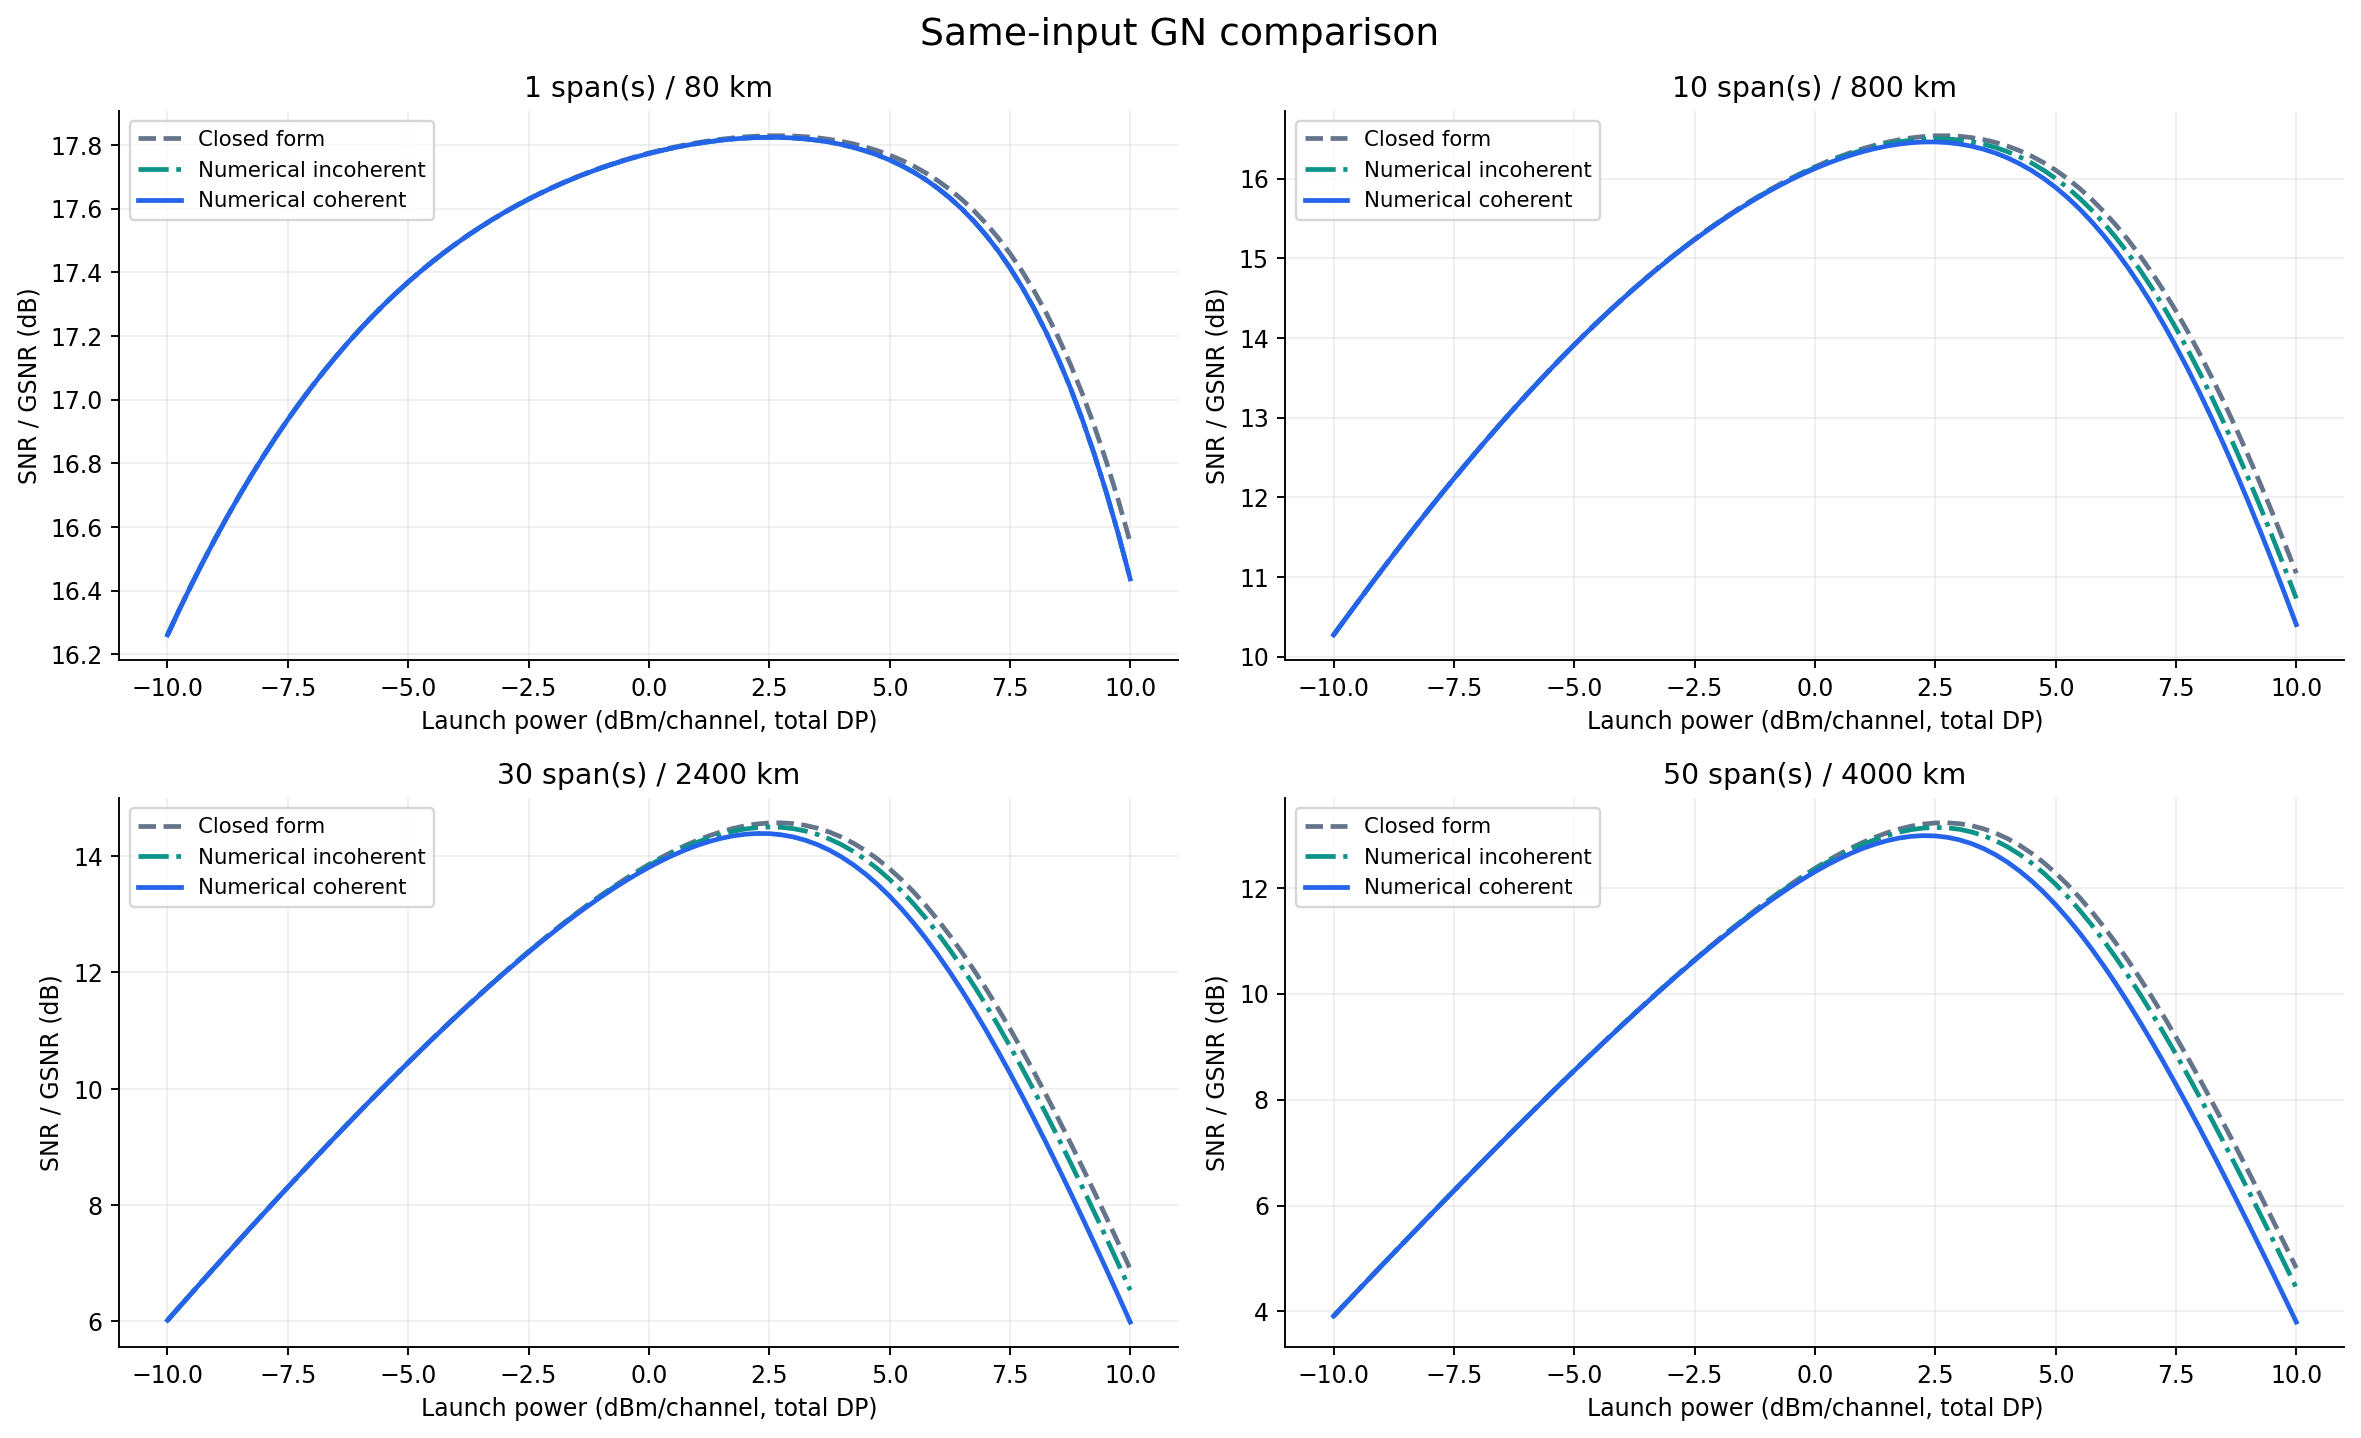

baseline,comparison,spans,eta_delta_pct,SNR_MAE_dB,SNR_RMSE_dB,SNR_MAPE_linear_pct,delta_Popt_dB,delta_SNRopt_dB
Closed form,Numerical incoherent,1,9.56678,0.0151864,0.0310351,0.347143,-0.132263,-0.00516404
Closed form,Numerical incoherent,10,9.56678,0.066354,0.116314,1.49265,-0.132263,-0.0382122
Closed form,Numerical incoherent,30,9.56678,0.0950717,0.15622,2.12585,-0.132263,-0.0726543
Closed form,Numerical incoherent,50,9.56678,0.105319,0.169757,2.35046,-0.132263,-0.0886321
Closed form,Numerical coherent,1,9.56671,0.0151863,0.0310349,0.347141,-0.132262,-0.005164
Closed form,Numerical coherent,10,20.2852,0.137204,0.23938,3.01296,-0.267374,-0.0781072
Closed form,Numerical coherent,30,25.6758,0.243584,0.397626,5.21244,-0.330839,-0.183604
Closed form,Numerical coherent,50,28.1743,0.29311,0.469048,6.20194,-0.359336,-0.242859
Numerical incoherent,Numerical coherent,1,-6.90209e-05,1.19176e-07,2.43028e-07,2.74412e-06,9.99181e-07,3.95852e-08
Numerical incoherent,Numerical coherent,10,9.78258,0.0708505,0.123072,1.59201,-0.135111,-0.0398951


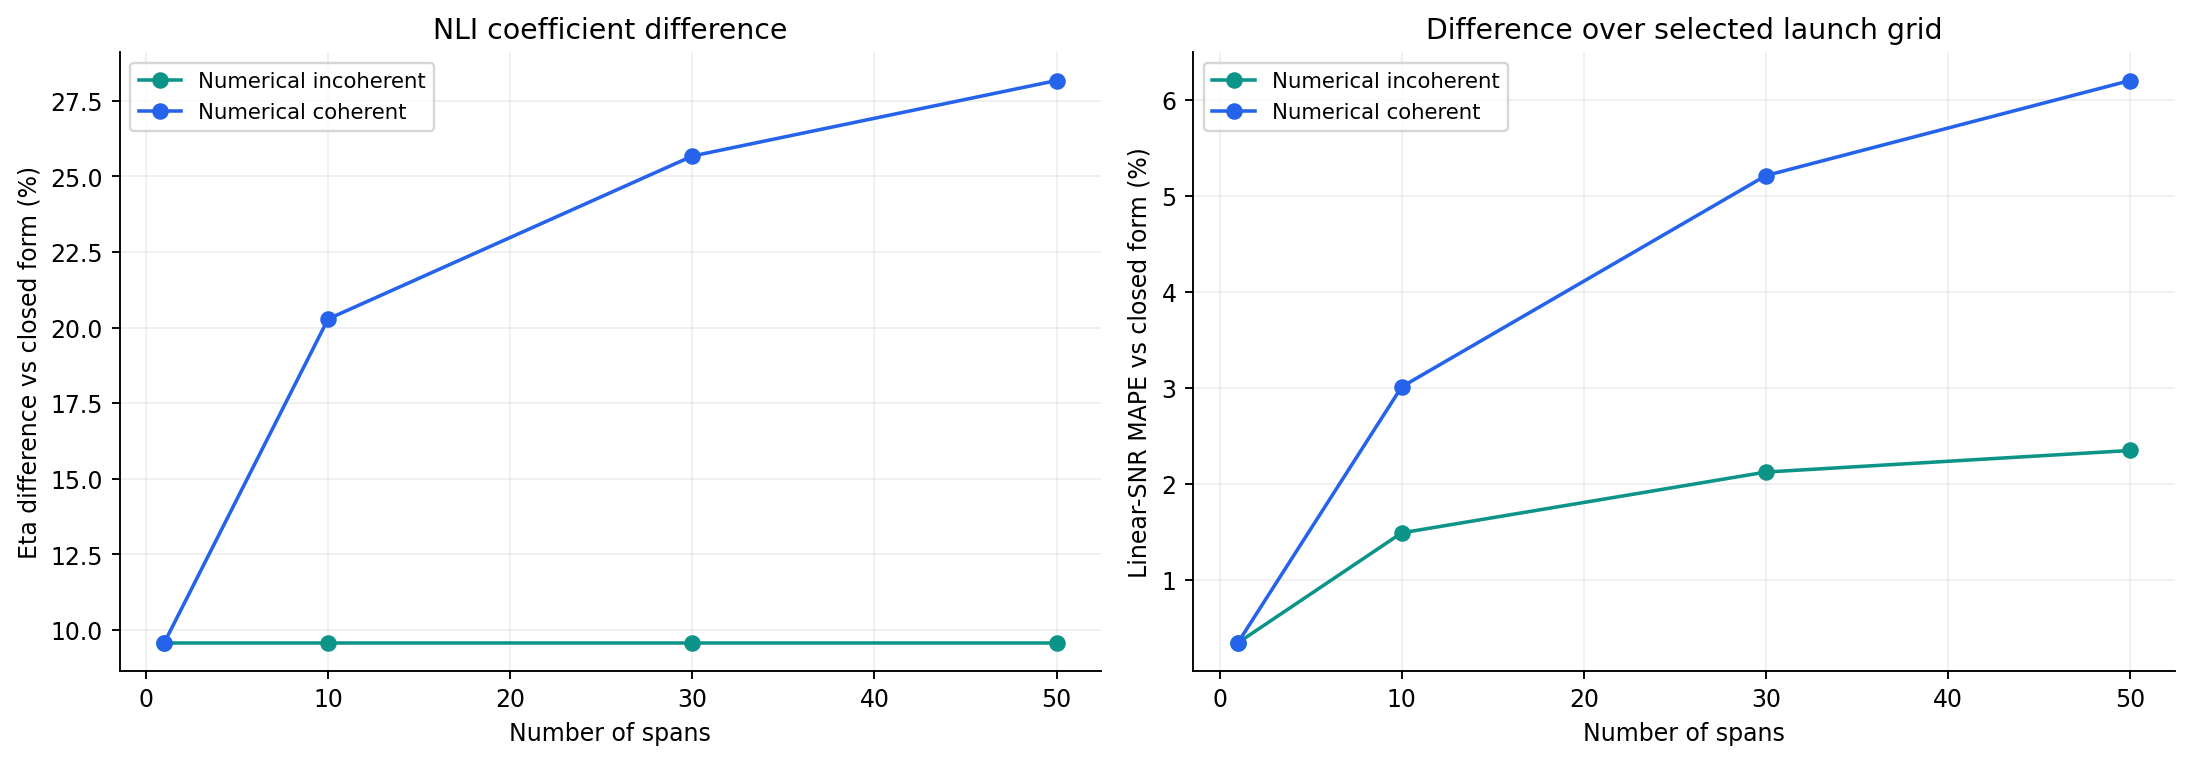

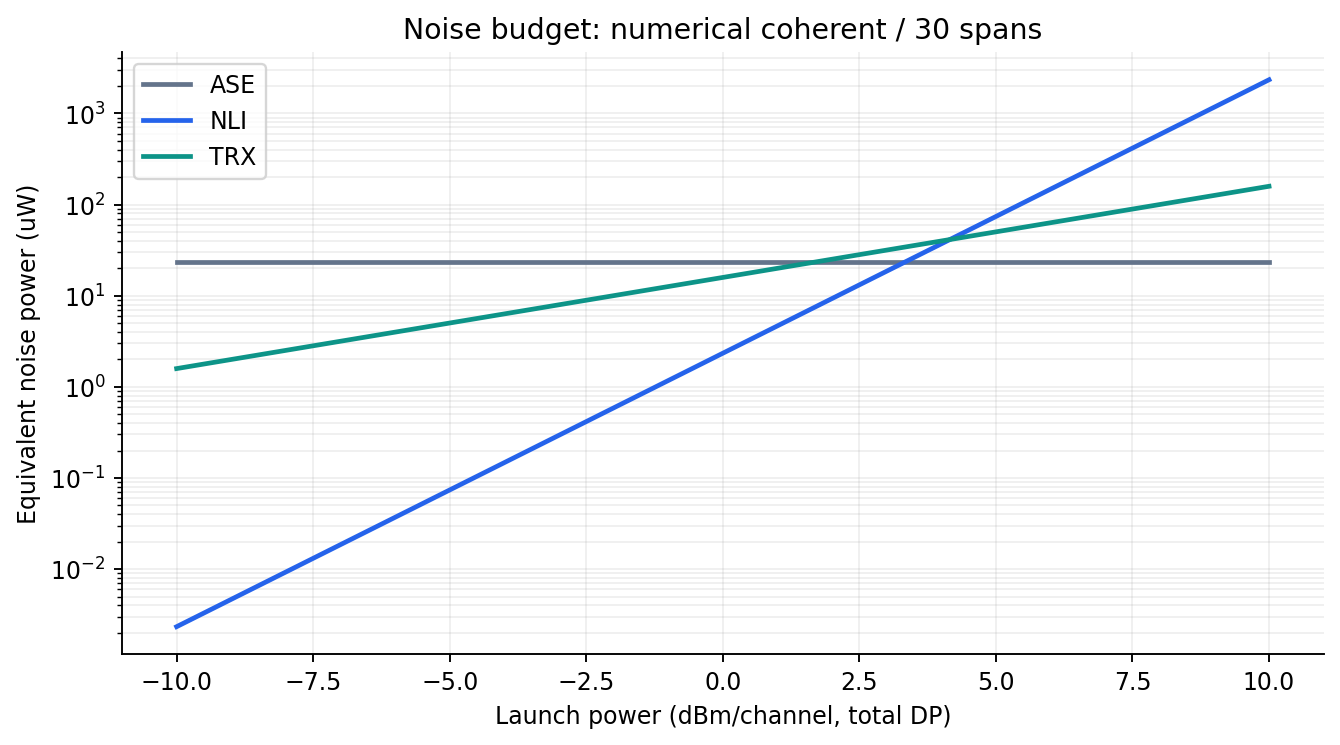

In [8]:
#@title 모델별 SNR 및 차이율
section("3. SNR와 모델 간 차이", "<p>회색: 원본 closed form / 청록: 수치 incoherent / 파랑: 수치 coherent. "
        "표의 MAPE는 선형 SNR 기준이며, 외부 실험 오차와 구분합니다.</p>")
ncols=min(2,len(SPANS)); nrows=math.ceil(len(SPANS)/ncols)
fig,axes=plt.subplots(nrows,ncols,figsize=(7*ncols,4.3*nrows),squeeze=False)
for ax,n in zip(axes.flat,SPANS):
    for model in MODELS:
        group=curves[(curves.model==model)&(curves.spans==n)]
        ax.plot(group.launch_dbm,group.snr_db,label=model,color=COLOR[model],ls=STYLE[model],lw=2)
    if external is not None:
        ref=external[external.spans==n]
        ax.scatter(ref.launch_dbm,ref.snr_db,label="External reference",color="#b45309",marker="x",zorder=5)
    ax.set(title=f"{n} span(s) / {n*SPAN_LENGTH_KM:g} km",xlabel="Launch power (dBm/channel, total DP)",
           ylabel="SNR / GSNR (dB)")
    ax.grid(alpha=.2); ax.legend(fontsize=9)
for ax in list(axes.flat)[len(SPANS):]: ax.set_visible(False)
fig.suptitle("Same-input GN comparison"+CONVERGENCE_SUFFIX,fontsize=16)
fig.tight_layout()
figure("snr_comparison",fig,"동일 입력의 launch power–SNR 비교. span 수가 같아야 직접 비교가 가능합니다.")

pairs=[("Closed form","Numerical incoherent"),
       ("Closed form","Numerical coherent"),
       ("Numerical incoherent","Numerical coherent")]
difference_rows=[]
for base,target in pairs:
    for n in SPANS:
        y0=curves[(curves.model==base)&(curves.spans==n)].snr_db.to_numpy()
        y1=curves[(curves.model==target)&(curves.spans==n)].snr_db.to_numpy()
        metrics=gn.error_metrics(y0,y1)
        p0=optima[(optima.model==base)&(optima.spans==n)].iloc[0]
        p1=optima[(optima.model==target)&(optima.spans==n)].iloc[0]
        difference_rows.append({"baseline":base,"comparison":target,"spans":n,
            "eta_delta_pct":100*(ETA[target][n]/ETA[base][n]-1),
            "SNR_MAE_dB":metrics["mae_db"],"SNR_RMSE_dB":metrics["rmse_db"],
            "SNR_MAPE_linear_pct":metrics["mape_linear_snr_percent"],
            "delta_Popt_dB":p1.optimum_launch_dBm-p0.optimum_launch_dBm,
            "delta_SNRopt_dB":p1.optimum_SNR_dB-p0.optimum_SNR_dB})
differences=table("model_differences",difference_rows,"모델 간 차이율 — 외부 정답 기준 오차 아님")

fig,axes=plt.subplots(1,2,figsize=(13,4.6))
for target in MODELS[1:]:
    d=differences[(differences.baseline=="Closed form")&(differences.comparison==target)]
    axes[0].plot(d.spans,d.eta_delta_pct,"o-",label=target,color=COLOR[target])
    axes[1].plot(d.spans,d.SNR_MAPE_linear_pct,"o-",label=target,color=COLOR[target])
axes[0].set(xlabel="Number of spans",ylabel="Eta difference vs closed form (%)",title="NLI coefficient difference")
axes[1].set(xlabel="Number of spans",ylabel="Linear-SNR MAPE vs closed form (%)",title="Difference over selected launch grid")
for ax in axes:
    ax.grid(alpha=.2); ax.legend(fontsize=9)
fig.tight_layout()
figure("model_differences",fig,"모델 간 차이율. NLI 계수의 차이율과 SNR의 차이율은 서로 다릅니다.")

focus_span=30 if 30 in SPANS else SPANS[-1]
focus_curve=curves[(curves.model=="Numerical coherent")&(curves.spans==focus_span)]
fig,ax=plt.subplots(figsize=(8,4.5))
for column,label,color in [("ase_w","ASE","#64748b"),("nli_w","NLI","#2563eb"),
                           ("trx_equivalent_noise_w","TRX","#0d9488")]:
    if np.any(focus_curve[column].to_numpy()>0):
        ax.semilogy(focus_curve.launch_dbm,focus_curve[column]*1e6,label=label,color=color,lw=2)
ax.set(title=f"Noise budget: numerical coherent / {focus_span} spans"+CONVERGENCE_SUFFIX,
       xlabel="Launch power (dBm/channel, total DP)",ylabel="Equivalent noise power (uW)")
ax.grid(alpha=.2,which="both"); ax.legend(); fig.tight_layout()
figure("noise_budget",fig,"ASE는 전력 sweep에서 일정, NLI는 P³, TRX 등가잡음은 P에 비례합니다.")

section("4. 외부 기준에 대한 오차율")
if external is None:
    note("미평가: 외부 논문·실험·SSFM SNR 데이터가 입력되지 않았습니다. 논문 일치율이나 실험 정확도를 산출하지 않았습니다.")
else:
    table("external_metrics",external_metrics,"외부 기준: "+REFERENCE_LABEL)
    note("외부 데이터와 입력 조건·편광 전력 기준·ASE 대역폭·TRX 포함 여부가 일치해야 위 오차율을 해석할 수 있습니다.")

## 6. 수치적분 수렴 및 seed 변경 검사

`rtol=0.001`은 0.1% 목표입니다. 독립 scramble들로 추정한 95% 구간 반폭과
직전 단계 대비 변화율이 모두 목표 이하이면 수렴으로 표시합니다.
이 수치는 모델-실험 오차가 아니며 통계적 진단이므로 엄밀한 오차 상한도 아닙니다.

model,spans,power,samples_per_scramble,eta_link_W^-2,estimated_95_halfwidth_pct,level_change_pct,all_requested_spans_converged
Numerical incoherent,1,18,262144,67.9045,0.00119367,0.00121961,True
Numerical incoherent,10,18,262144,679.045,0.00119367,0.00121961,True
Numerical incoherent,30,18,262144,2037.13,0.00119367,0.00121961,True
Numerical incoherent,50,18,262144,3395.22,0.00119367,0.00121961,True
Numerical coherent,1,20,1048576,67.9044,0.00042001,0.000188219,True
Numerical coherent,10,20,1048576,745.473,0.0304781,0.00614468,True
Numerical coherent,30,20,1048576,2336.64,0.0412475,0.00809751,True
Numerical coherent,50,20,1048576,3971.83,0.0706295,0.0160045,True


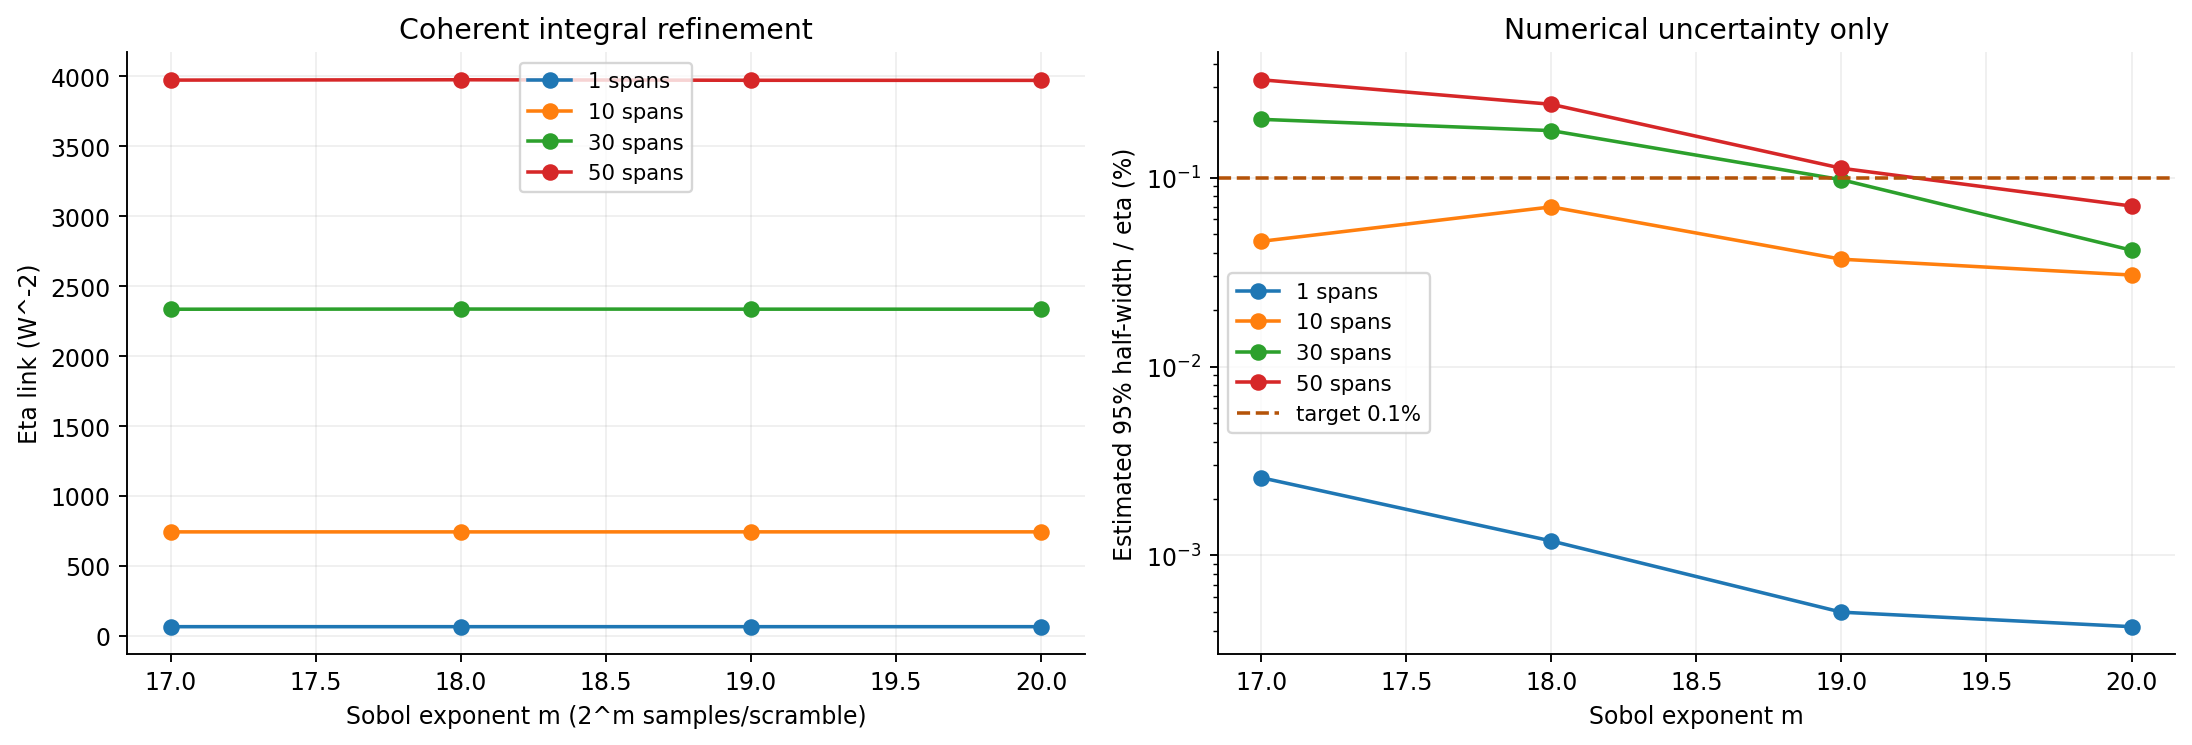

Coherent cross-check seed=73
2^17/scramble: estimated 95% half-width <= 0.5412%, level change <= n/a, 0.6s
2^18/scramble: estimated 95% half-width <= 0.3605%, level change <= 0.3212%, 1.2s
2^19/scramble: estimated 95% half-width <= 0.1602%, level change <= 0.0084%, 2.4s
2^20/scramble: estimated 95% half-width <= 0.1297%, level change <= 0.0393%, 5.0s
2^21/scramble: estimated 95% half-width <= 0.0745%, level change <= 0.0829%, 10.5s


spans,seed_1,seed_2,eta_seed_1_W^-2,eta_seed_2_W^-2,absolute_difference_pct,seed_1_converged,seed_2_converged
1,20260909,73,67.9044,67.9045,0.000102205,True,True
10,20260909,73,745.473,745.348,0.0167347,True,True
30,20260909,73,2336.64,2336.49,0.00671793,True,True
50,20260909,73,3971.83,3972.47,0.0160706,True,True


In [9]:
#@title 수렴 이력 및 독립 seed 재계산
section("5. 수치적분 정밀도", "<p>추정 95% 구간 반폭과 단계 간 변화율을 함께 확인합니다. "
        "서로 다른 seed로 다시 계산해 결과의 안정성도 점검합니다.</p>")
convergence_rows=[]
for label,result in [("Numerical incoherent",eta_incoherent),("Numerical coherent",eta_coherent)]:
    for state in result["history"]:
        for j,n in enumerate(result["spans"]):
            convergence_rows.append({"model":label,"spans":n,"power":state["power"],
                "samples_per_scramble":state["samples_per_replicate"],"eta_link_W^-2":state["eta_link_w_inv2"][j],
                "estimated_95_halfwidth_pct":100*state["relative_ci95_halfwidth"][j],
                "level_change_pct":None if state["relative_change"] is None else 100*state["relative_change"][j],
                "all_requested_spans_converged":state["converged"]})
convergence=pd.DataFrame(convergence_rows)
TABLES["convergence_history"]=convergence
last_convergence=convergence.groupby(["model","spans"],sort=False).tail(1)
table("convergence_final",last_convergence,"최종 적분 단계의 수렴 진단")
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for n in SPANS:
    group=convergence[(convergence.model=="Numerical coherent")&(convergence.spans==n)]
    axes[0].plot(group.power,group["eta_link_W^-2"],"o-",label=f"{n} spans")
    axes[1].semilogy(group.power,np.maximum(group.estimated_95_halfwidth_pct,1e-12),"o-",label=f"{n} spans")
axes[0].set(xlabel="Sobol exponent m (2^m samples/scramble)",ylabel="Eta link (W^-2)",title="Coherent integral refinement")
axes[1].axhline(100*RTOL,color="#b45309",ls="--",label=f"target {100*RTOL:g}%")
axes[1].set(xlabel="Sobol exponent m",ylabel="Estimated 95% half-width / eta (%)",title="Numerical uncertainty only")
for ax in axes: ax.grid(alpha=.2); ax.legend(fontsize=9)
fig.tight_layout()
figure("convergence",fig,"샘플 수 증가에 따른 eta와 추정 불확도. 전체 수렴 이력은 CSV/JSON에 저장됩니다.")

seed_result=None
seed_checks=pd.DataFrame()
if RUN_SEED_CHECK:
    seed_result=run_numerical("Coherent cross-check seed="+str(CHECK_SEED),replace(options,seed=CHECK_SEED))
    rows=[]
    for j,n in enumerate(SPANS):
        baseline=eta_coherent["eta_link_w_inv2"][j]
        other=seed_result["eta_link_w_inv2"][j]
        rows.append({"spans":n,"seed_1":SEED,"seed_2":CHECK_SEED,
            "eta_seed_1_W^-2":baseline,"eta_seed_2_W^-2":other,
            "absolute_difference_pct":100*abs(other-baseline)/baseline,
            "seed_1_converged":eta_coherent["converged"],"seed_2_converged":seed_result["converged"]})
    seed_checks=table("seed_crosscheck",rows,"독립 seed 간 재계산 차이")
else:
    note("seed 재계산을 끈 상태입니다. 새 입력의 정밀도를 확인할 때 활성화하세요.")

## 7. 독립 적분으로 구현 확인

이 검사는 주 계산과 별도로, **1채널·32 GBd·SMF 조건**을 사용합니다.
같은 GN 적분을 다른 방식인 Gauss–Legendre 적분으로 계산하며, Sobol 중요도 좌표변환을 사용하지 않습니다.
64점과 96점 Gauss 결과가 가까운지도 확인한 후 기준으로 사용합니다.

여기서 구한 오차율은 **이 별도 수학 검증 조건의 오차**입니다. 90채널 G.654.E나 논문값에 대한 오차로 해석하지 않습니다.

In [10]:
#@title 독립 Gauss 적분 함수
def gauss_single_channel(fiber, system, spans=1, order=72, coherent=True):
    """Independent DIRECT tensor Gauss quadrature; no Sobol/importance transform.

    Rectangular single channel, receiver integrated. Split u at 0 so each
    v-domain bound is smooth. Useful for moderate-dispersion narrowband tests;
    this coarse rule is NOT used as a reference for a many-THz WDM comb.
    """
    p = gn.derive_parameters(fiber, system)
    a, L = p["alpha_power_per_km"], system.span_length_km
    k = 4 * np.pi**2 * p["beta2_s2_per_km"] * p["rate_hz"]**2
    nodes, weights = leggauss(order)
    value = 0.0
    for x, wx in zip(nodes / 2, weights / 2):
        for low, high in ((-0.5 - x, 0.0), (0.0, 0.5 - x)):
            u = (low + high) / 2 + (high - low) / 2 * nodes
            wu = weights * (high - low) / 2
            vl = np.maximum(-0.5 - x, -0.5 - x - u)
            vh = np.minimum(0.5 - x, 0.5 - x - u)
            v = (vl[:, None] + vh[:, None]) / 2 + (vh - vl)[:, None] * nodes / 2
            wv = weights * (vh - vl)[:, None] / 2
            db = k * u[:, None] * v
            # Independent complex exponential expression for the same exact kernel.
            link = -np.expm1((-a + 1j * db) * L) / (a - 1j * db)
            if coherent:
                phases = np.zeros_like(db, dtype=complex)
                for n in range(spans):
                    phases += np.exp(1j * n * db * L)
                kernel = np.abs(link * phases)**2
            else:
                kernel = spans * np.abs(link)**2
            value += wx * np.sum(wu[:, None] * wv * kernel)
    return (16 / 27) * p["gamma_per_w_km"]**2 * value

In [11]:
#@title 독립 적분 검증과 물리적 scaling 확인
section("6. 독립 구현 검사", "<p>주 링크와 별개인 좁은 대역의 검증 조건에서 독립 Gauss 적분을 비교합니다. "
        "큰 WDM 대역에 저해상도 Gauss 격자를 그대로 정답처럼 사용하지 않습니다.</p>")
independent_table=pd.DataFrame()
independent_result=None
independent_context=None
if RUN_INDEPENDENT_CHECK:
    check_fiber=gn.FiberParameters(name="SMF mathematical fixture",attenuation_db_per_km=0.2,
        dispersion_ps_nm_km=16.7,effective_area_um2=80)
    check_system=gn.SystemParameters(channels=1,symbol_rate_gbd=32,spacing_ghz=50,
        span_length_km=80,stated_gain_bandwidth_thz=None)
    check_options=gn.NumericalGNOptions(min_power=14,max_power=20,replicates=8,
        relative_tolerance=0.001,seed=20260909)
    independent_context={"fiber":asdict(check_fiber),"system":asdict(check_system),
                         "options":asdict(check_options),"spans":[1,3]}
    independent_result=gn.numerical_gn_eta([1,3],fiber=check_fiber,system=check_system,options=check_options)
    rows=[]
    for n,eta in zip(independent_result["spans"],independent_result["eta_link_w_inv2"]):
        q64=gauss_single_channel(check_fiber,check_system,n,64)
        q96=gauss_single_channel(check_fiber,check_system,n,96)
        reference_stable=abs(q96/q64-1)<1e-5
        rows.append({"spans":n,"GN_Sobol_eta_W^-2":eta,"Gauss64_eta_W^-2":q64,
            "Gauss96_eta_W^-2":q96,"Gauss_64_96_change_pct":100*abs(q96/q64-1),
            "numerical_abs_error_pct":100*abs(eta/q96-1) if reference_stable else np.nan,
            "Gauss_reference_stable":reference_stable,"Sobol_converged":independent_result["converged"]})
    independent_table=table("independent_quadrature",rows,"별도 1채널 조건의 수치적분 오차율")
    table("independent_inputs",[{"분류":category,"변수":key,"값":str(value)}
        for category,settings in independent_context.items() if isinstance(settings,dict)
        for key,value in settings.items()],"독립 검사에 사용한 입력값 — 주 링크와 다름")
else:
    note("독립 적분 검사를 끈 상태입니다.")

physical_rows=[]
a,L=parameters["alpha_power_per_km"],SPAN_LENGTH_KM
ratio_kernel=float(gn.single_span_kernel(0,a,L))/parameters["effective_length_km"]**2
physical_rows.append({"검사":"위상 0에서 rho / Leff²","계산":ratio_kernel,"기대":1.0,
    "통과":bool(np.isclose(ratio_kernel,1,rtol=1e-12))})
phase=np.array([0.,.17,-.71,2*np.pi,5.2])
direct=np.abs(np.sum(np.exp(1j*np.arange(7)[:,None]*phase),axis=0))**2
phase_error=float(np.max(np.abs(gn.coherent_accumulation(phase,7)-direct)))
physical_rows.append({"검사":"coherent 직접 복소합 최대 절대 차이","계산":phase_error,"기대":0.0,"통과":phase_error<1e-10})
scale=gn.calculate_snr([0,10*np.log10(2)],focus_span,ETA["Numerical coherent"][focus_span],
                      parameters,system,include_transceiver_noise=INCLUDE_TRX)
ratio_power=float(scale["nli_w"][1]/scale["nli_w"][0])
physical_rows.append({"검사":"전력 2배 → NLI 배율","계산":ratio_power,"기대":8.0,
    "통과":bool(np.isclose(ratio_power,8,rtol=1e-12))})
per_span=np.array(eta_incoherent["eta_link_w_inv2"])/np.array(SPANS)
incoherent_spread=float(np.max(np.abs(per_span/per_span[0]-1)))
physical_rows.append({"검사":"incoherent eta/N 상대 편차","계산":incoherent_spread,"기대":0.0,"통과":incoherent_spread<1e-12})
physical_checks=table("physical_identity_checks",physical_rows,"수식 항등식과 전력 scaling 확인")

spans,GN_Sobol_eta_W^-2,Gauss64_eta_W^-2,Gauss96_eta_W^-2,Gauss_64_96_change_pct,numerical_abs_error_pct,Gauss_reference_stable,Sobol_converged
1,145.302,145.303,145.303,4.44089e-14,0.00133868,True,True
3,602.706,602.405,602.405,4.44089e-14,0.0499047,True,True


분류,변수,값
fiber,name,SMF mathematical fixture
fiber,wavelength_nm,1550.0
fiber,attenuation_db_per_km,0.2
fiber,effective_area_um2,80
fiber,dispersion_ps_nm_km,16.7
fiber,n2_m2_w,2.2e-20
fiber,alpha_power_per_km,None
fiber,beta2_s2_per_km,None
fiber,gamma_per_w_km,None
system,channels,1


검사,계산,기대,통과
위상 0에서 rho / Leff²,1,1,True
coherent 직접 복소합 최대 절대 차이,4.66294e-15,0,True
전력 2배 → NLI 배율,8,8,True
incoherent eta/N 상대 편차,0,0,True


## 8. 자동 해석 — 차이·오차가 발생한 이유

입력이나 실행 결과를 바꾸면 아래 숫자와 판정 문구도 다시 계산됩니다.
5% 기준은 주의해서 볼 차이를 표시하는 보고서용 기준이며, GN 모델의 합격/불합격 기준은 아닙니다.

In [15]:
#@title 결과 요약 및 원인 분석
section("7. 결과 해석과 오차 원인")
foc=optima[(optima.model=="Numerical coherent")&(optima.spans==focus_span)].iloc[0]
cf_i=differences[(differences.baseline=="Closed form")&(differences.comparison=="Numerical incoherent")
                 &(differences.spans==focus_span)].iloc[0]
i_c=differences[(differences.baseline=="Numerical incoherent")&(differences.comparison=="Numerical coherent")
                &(differences.spans==focus_span)].iloc[0]
uncertainty_max=float(last_convergence.estimated_95_halfwidth_pct.max())
phase_gain=float(i_c.eta_delta_pct)
status="수렴 기준 충족" if NUMERICAL_CONVERGED else "미수렴: 잠정 결과"
SUMMARY={"focus_spans":focus_span,"distance_km":focus_span*SPAN_LENGTH_KM,
    "numerical_coherent_eta_link_W_inv2":float(foc["eta_link_W^-2"]),
    "optimum_launch_dbm":float(foc.optimum_launch_dBm),"optimum_snr_db":float(foc.optimum_SNR_dB),
    "closed_to_numerical_incoherent_eta_difference_pct":float(cf_i.eta_delta_pct),
    "incoherent_to_coherent_eta_difference_pct":phase_gain,
    "max_estimated_numerical_95_halfwidth_pct":uncertainty_max,
    "numerical_models_converged":bool(NUMERICAL_CONVERGED),
    "external_validation_status":"not_evaluated" if external is None else "evaluated_for_supplied_SNR_data",
    "fitting_applied":False}
section("결과 설명",
    f"<p>{html.escape(FIBER_NAME)}, {CHANNELS}채널, {focus_span} spans ({focus_span*SPAN_LENGTH_KM:g} km)에서 "
    f"수치 GN coherent가 계산한 최적 송신전력은 채널당 <b>{foc.optimum_launch_dBm:.3f} dBm</b>, "
    f"그때 SNR는 <b>{foc.optimum_SNR_dB:.3f} dB</b>입니다. 현재 적분 상태는 <b>{status}</b>입니다.</p>"
    f"<p>span 누적을 같게 놓고 계산 방법만 바꾸면 NLI 계수가 원본보다 {cf_i.eta_delta_pct:+.3f}% 달라집니다. "
    f"위상 누적까지 반영하면 수치 incoherent 대비 {phase_gain:+.3f}% 달라집니다. "
    "이는 계산 가정의 차이를 보여주며, 논문이나 실험에 더 가깝다는 증명은 아닙니다.</p>")

cause_rows=[
    {"항목":"closed form → 주파수 적분","현재 관찰":f"eta {cf_i.eta_delta_pct:+.3f}% at {focus_span} spans",
     "원인/해석":"유한-span 커널·주파수 영역·수신 대역을 직접 계산한 효과의 합. 각 원인의 기여율을 따로 측정한 것은 아님."},
    {"항목":"incoherent → coherent","현재 관찰":f"eta {phase_gain:+.3f}% at {focus_span} spans",
     "원인/해석":"span 사이의 위상 관계를 반영하는 누적 가정 차이. 경험적 N^(1+epsilon) fitting 미사용."},
    {"항목":"수치적분 불확도","현재 관찰":f"최종 추정 95% 반폭 최대 {uncertainty_max:.5f}%",
     "원인/해석":"유한 샘플 및 진동하는 위상항. 샘플/독립 scramble/seed를 늘려 점검; 물리적 모델 오차와 별개."},
    {"항목":"전력·잡음 기준","현재 관찰":f"total DP/channel, ASE B={parameters['ase_bandwidth_hz']/1e9:g} GHz, TRX={INCLUDE_TRX}",
     "원인/해석":"비교 데이터가 편광당 전력, 0.1 nm OSNR, 다른 TRX 조건이면 체계적인 차이가 발생할 수 있음."},
    {"항목":"GN 모델의 물리적 근사","현재 관찰":"외부 데이터로 확인 필요",
     "원인/해석":"가우시안 신호 가정은 유지. EGN 변조 보정, ISRS/Raman, beta3, 파장별 물성, 필터/PMD/PDL 미포함."},
]
if SUPPORT_THZ>STATED_GAIN_BANDWIDTH_THZ:
    cause_rows.append({"항목":"입력 대역폭 불일치","현재 관찰":f"{SUPPORT_THZ:g} vs {STATED_GAIN_BANDWIDTH_THZ:g} THz",
        "원인/해석":"실제 증폭 대역과 WDM 배치의 정합 필요. 적분 정밀도 향상만으로 해결되지 않음."})
table("difference_causes",cause_rows,"차이·오차의 가능한 원인과 확인 방법")

large=differences[(differences.eta_delta_pct.abs()>5)|(differences.SNR_MAPE_linear_pct>5)]
if not large.empty:
    note(f"5%를 초과한 모델 간 차이가 {len(large)}개 비교 행에서 확인되었습니다. "
         "이는 수치적분이 5% 틀렸다는 뜻이 아닙니다. 누적 방식과 근사 범위를 먼저 맞춰 해석해야 합니다.","warning")
if external is not None:
    if np.any(external_metrics.mape_linear_snr_percent>5):
        note("외부 기준 SNR MAPE가 5%를 넘는 항목이 있습니다. 전력/편광 정의, ASE·TRX, "
             "채널 스펙트럼과 span 조건을 먼저 대조하고, 이후 GN의 가우시안 가정 및 누락 물리를 검토하세요. "
             "외부 데이터만으로 특정 원인이 확정된 것은 아닙니다.","warning")
    table("external_model_ranking",external_metrics.sort_values(["spans","rmse_db"]),
          "외부 기준 오차 비교 — 각 span에서 RMSE가 작은 순")
else:
    note("최종 판단: 수치 GN의 구현·적분 정밀도를 점검한 상태입니다. 외부 기준이 없으므로 실제 성능의 정확도 등급이나 논문 오차율은 미평가입니다.")

section("전공자용 활용 판단",
    "<p>동일-span, lumped EDFA, 일정 alpha/beta2/gamma, 동일 채널 전력·심볼률, 비중첩 직사각형 스펙트럼의 "
    "total-DP GN 적분 평가기로 사용할 수 있습니다. eta_link에는 span 누적과 수신대역 적분이 포함됩니다. "
    "coherent와 incoherent 선택을 외부 기준 모델에 맞추고, 수렴 이력을 함께 보존해야 합니다.</p>"
    "<p>본 검사만으로 실험 예측의 범용 정확도를 확정할 수 없습니다. 최대거리/용량 계산에는 별도 BER·FEC·AIR 또는 "
    "Shannon-gap 가정이 필요합니다. EGN/SSFM/실험과 비교하려면 동일 조건의 외부 기준을 추가해야 합니다.</p>")

항목,현재 관찰,원인/해석
closed form → 주파수 적분,eta +9.567% at 30 spans,유한-span 커널·주파수 영역·수신 대역을 직접 계산한 효과의 합. 각 원인의 기여율을 따로 측정한 것은 아님.
incoherent → coherent,eta +14.702% at 30 spans,span 사이의 위상 관계를 반영하는 누적 가정 차이. 경험적 N^(1+epsilon) fitting 미사용.
수치적분 불확도,최종 추정 95% 반폭 최대 0.07063%,유한 샘플 및 진동하는 위상항. 샘플/독립 scramble/seed를 늘려 점검; 물리적 모델 오차와 별개.
전력·잡음 기준,"total DP/channel, ASE B=95 GHz, TRX=True","비교 데이터가 편광당 전력, 0.1 nm OSNR, 다른 TRX 조건이면 체계적인 차이가 발생할 수 있음."
GN 모델의 물리적 근사,외부 데이터로 확인 필요,"가우시안 신호 가정은 유지. EGN 변조 보정, ISRS/Raman, beta3, 파장별 물성, 필터/PMD/PDL 미포함."
입력 대역폭 불일치,8.55 vs 4.8 THz,실제 증폭 대역과 WDM 배치의 정합 필요. 적분 정밀도 향상만으로 해결되지 않음.


## 9. 보고서 파일 생성 및 다운로드

입력값·계산 결과·차이율·수렴 이력·모델 소스를 자동 저장합니다.
HTML은 그래프가 내장된 보고서이며, ZIP에는 CSV/JSON/PNG 및 사용한 코드가 포함됩니다.
실행마다 별도 폴더를 생성해 이전 결과를 보존합니다.

In [13]:
#@title HTML/CSV/JSON/그림/코드 저장
section("8. 출처와 재현 정보",
    '<p>원본: <a href="https://github.com/kimheeseo/LSCNS/blob/main/2026_KICS_Fall/main.py">'
    'kimheeseo/LSCNS — 2026_KICS_Fall/main.py</a><br>'
    'GN 식: <a href="https://arxiv.org/abs/1209.0394">Poggiolini et al., A Detailed Analytical Derivation '
    'of the GN Model…, Eq. (96)/(G.4)</a><br>'
    'Sobol: <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.Sobol.html">'
    'SciPy 공식 문서</a></p>')
provenance={"run_id_utc":RUN_ID,"source_git_blob_sha":ORIGINAL_BLOB_SHA,
    "numerical_source_sha256":NUMERICAL_SHA256,
    "python":sys.version.split()[0],"numpy":np.__version__,"scipy":scipy.__version__,
    "pandas":pd.__version__,"matplotlib":matplotlib.__version__,
    "source_policy":"Embedded fixed snapshots; no live GitHub dependency; no fit function called"}
table("provenance",[{"항목":k,"값":str(v)} for k,v in provenance.items()],"실행 및 소스 버전")
metadata={"provenance":provenance,"fiber":asdict(fiber),"system":asdict(system),
    "options":asdict(options),"spans":SPANS,"launch_dbm":LAUNCH.tolist(),
    "include_transceiver_noise":INCLUDE_TRX,"derived_parameters":parameters,
    "reference_csv":REFERENCE_CSV,"reference_label":REFERENCE_LABEL,
    "reference_status":SUMMARY["external_validation_status"],"independent_fixture":independent_context,
    "numerical_incoherent":eta_incoherent,"numerical_coherent":eta_coherent,
    "seed_crosscheck":seed_result,"independent_integral":independent_result,
    "warnings":list(dict.fromkeys(RUN_WARNINGS)),"summary":SUMMARY}
with (OUTPUT_DIR/"run_metadata.json").open("w",encoding="utf-8") as stream:
    json.dump(metadata,stream,ensure_ascii=False,indent=2,allow_nan=False)
for name,frame in TABLES.items():
    frame.to_csv(OUTPUT_DIR/(name+".csv"),index=False,encoding="utf-8-sig")
for name,payload in FIGURES.items():
    (OUTPUT_DIR/(name+".png")).write_bytes(payload)
for filename,source in SOURCE_FILES.items():
    (OUTPUT_DIR/filename).write_text(source,encoding="utf-8")

CSS='''body{font-family:'Noto Sans KR','Malgun Gothic',Arial,sans-serif;background:#f1f5f9;color:#172554;margin:0;line-height:1.7}
main{max-width:1160px;margin:32px auto;background:white;padding:48px;border-radius:14px;box-shadow:0 8px 28px #0f172a10}
h1{font-size:30px;line-height:1.3;margin:0 0 14px}h2{font-size:22px;margin-top:40px;border-top:1px solid #dbeafe;padding-top:20px}
h3{font-size:16px;margin-top:22px}p{color:#334155}.kicker{font-size:12px;letter-spacing:2px;color:#2563eb;font-weight:bold}
.lead{font-size:17px}.note,.warning{padding:14px 18px;background:#eff6ff;border-left:4px solid #2563eb;margin:18px 0;color:#1e3a8a}
.warning{background:#fffbeb;border-color:#d97706;color:#78350f}.table-scroll{overflow-x:auto;margin:15px 0}
table{width:100%;border-collapse:collapse;font-size:12px;color:#1e293b}th{background:#eff6ff;text-align:left;border-bottom:2px solid #bfdbfe}
th,td{padding:9px 10px;border-bottom:1px solid #e2e8f0;vertical-align:top}tr:nth-child(even){background:#f8fafc}
figure{margin:24px 0}img{max-width:100%;height:auto}figcaption{font-size:13px;color:#475569}a{color:#1d4ed8;overflow-wrap:anywhere}
code{background:#eff6ff;padding:2px 5px}footer{margin-top:35px;color:#64748b;font-size:12px}
@media print{body{background:white}main{margin:0;padding:0;box-shadow:none}h2,figure{break-inside:avoid}.table-scroll{overflow:visible}}
'''
title="수치 GN 모델 검증·비교 보고서"
intro=(f'<div class="kicker">GN MODEL · NUMERICAL INTEGRATION REPORT</div><h1>{title}</h1>'
       f'<p class="lead">{html.escape(FIBER_NAME)} / {CHANNELS} WDM / {SYMBOL_RATE_GBD:g} GBd / '
       f'{SPAN_LENGTH_KM:g} km per span</p><p>실행 ID (UTC): {RUN_ID}</p>'
       '<div class="note"><b>해석 기준:</b> 모델 간 차이율, 수치적분 불확도, 외부 기준 오차율은 서로 다른 지표입니다. '
       '외부 SNR 데이터가 없으면 논문·실험 오차율은 미평가입니다.</div>')
HTML_REPORT=OUTPUT_DIR/"GN_numerical_report.html"
HTML_REPORT.write_text('<!doctype html><html lang="ko"><head><meta charset="utf-8">'
    '<meta name="viewport" content="width=device-width,initial-scale=1">'
    f'<title>{title}</title><style>{CSS}</style></head><body><main>{intro}'
    +''.join(REPORT_BLOCKS)+'<footer>본 보고서는 입력 조건과 모델 가정을 함께 확인해야 합니다. '
    'fitting은 적용하지 않았습니다.</footer></main></body></html>',encoding="utf-8")
summary_lines=["수치 GN 보고서 실행 요약",f"실행: {RUN_ID}",f"입력: {FIBER_NAME}, {CHANNELS}채널, {SPANS} spans",
    f"적분 수렴: {NUMERICAL_CONVERGED}",f"외부 데이터 평가: {SUMMARY['external_validation_status']}",
    "주요 파일: GN_numerical_report.html / run_metadata.json / snr_curves.csv / model_differences.csv",
    "주의: 모델 간 차이율은 실제값에 대한 오차율이 아닙니다. 상세 설명은 HTML 보고서 참조."]
(OUTPUT_DIR/"README.txt").write_text("\n".join(summary_lines),encoding="utf-8")
ZIP_PATH=OUTPUT_DIR.parent/("GN_report_"+RUN_ID+".zip")
with ZipFile(ZIP_PATH,"w",compression=ZIP_DEFLATED) as archive:
    for path in sorted(OUTPUT_DIR.iterdir()):
        if path.is_file(): archive.write(path,path.name)
print("보고서 생성 완료:",HTML_REPORT)
print("CSV/JSON/PNG/코드 묶음:",ZIP_PATH)
display(FileLink(str(HTML_REPORT)),FileLink(str(ZIP_PATH)))

항목,값
run_id_utc,20260910T005340_948727Z
source_git_blob_sha,7acd0ca1379592b6ad79acbe2748da4309830083
numerical_source_sha256,237bde9d149409ea4c17dea4d76e5747dd47e89ba7e92cab51e97350c7a7d838
python,3.13.15
numpy,2.1.3
scipy,1.16.3
pandas,2.2.3
matplotlib,3.10.0
source_policy,Embedded fixed snapshots; no live GitHub dependency; no fit function called


보고서 생성 완료: gn_colab_results/20260910T005340_948727Z/GN_numerical_report.html
CSV/JSON/PNG/코드 묶음: gn_colab_results/GN_report_20260910T005340_948727Z.zip


/content/gn_colab_results/20260910T005340_948727Z/GN_numerical_report.html

/content/gn_colab_results/GN_report_20260910T005340_948727Z.zip

In [14]:
#@title 결과 파일 다운로드 — Colab에서 체크 후 이 셀 실행
DOWNLOAD_RESULTS = False #@param {type:"boolean"}
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
    except ImportError:
        print("Colab 이외 환경: 위의 출력 경로에서 HTML/ZIP을 열 수 있습니다.")
    else:
        files.download(str(ZIP_PATH))
else:
    print("다운로드하려면 DOWNLOAD_RESULTS를 True로 바꾸고 이 셀을 실행하세요.")

다운로드하려면 DOWNLOAD_RESULTS를 True로 바꾸고 이 셀을 실행하세요.
